## Setup for EDA and time series 

In [1]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Data Viz. 
import statsmodels.formula.api as smf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.ndimage import gaussian_filter
from calendar import monthrange
from calendar import month_name
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report

from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.graphics.tsaplots import plot_pacf

from pmdarima.arima import auto_arima
import statsmodels.graphics.tsaplots as tsaplot
from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing, SimpleExpSmoothing


from statsmodels.tsa.statespace.sarimax import SARIMAX
#New Libraries
#from statsmodels.tsa.statespace.sarimax import SARIMAX
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'
cmaps_hex = ['#193251','#FF5A36','#696969', '#7589A2','#FF5A36', '#DB6668']
sns.set_palette(palette=cmaps_hex)
sns_c = sns.color_palette(palette=cmaps_hex)
%matplotlib inline
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi'] = 100


In [3]:
from statsmodels.tsa.stattools import adfuller
!pip install pmdarima --quiet
import pmdarima as pm
#require(forecast)

### Columns
|Name                | Description                                                                   | Type     |Energy Source
|---------------------|-------------------------------------------------------------------------------|----------|----------|
| Area       |     Whole Germany                          |object   |     |
| Mtu     |                                  | object  |    |
| Biomass_mwh         |     Biomass                 | float64 |Renewable |
| Fossil_brown_coal_mwh      | Fossil brown coal              | float64 |Fossil  Fuels|
| Fossil_coal_derived_gas_mwh    |    Fossil coal derived gas       | float64 |Fossil  Fuels |
| Fossil_gas_mwh      |      Fossil gas                | float64 |Fossil  Fuels|
| Fossil_hard_coal_mwh     |      Fossil hard coal           | float64 |Fossil  Fuels|
| Fossil_oil_mwh      |       Fossil oil               | float64 |Fossil  Fuels|
| Fossil_oil_shale_mwh     |    Fossil oil shale             | float64 |Fossil  Fuels   |
| Fossil_peat_mwh     |   Fossil peat                    | float64 |Fossil  Fuels |
| Geothermal_mwh    |        Geothermal                | float64 |Renewable|
| Hydro_pumped_storage_aggregated_mwh  | Hydro pumped storage (generation)    | float64 |    |
| Hydro_pumped_storage_consumption_mwh   | Hydro pumped storage (consumption)| float64 |    |
| Hydro_run_of_river_and_poundage_mwh   | Hydro run of river and poundage   | float64 |Renewable|
| Hydro_water_reservoir_mwh  |    Hydro water reservoir             | float64 |Renewable|
| Marine_mwh     |   Marine                        | float64 |Renewable|
| Nuclear_mwh  |       Nuclear                       | float64 |Nuclear   |
| Other_mwh     |       Other                     | float64 |    |
| Other_renewable_mwh     |    Other renewable              | float64 |Renewable|
| Solar_mwh     |      Solar                      | float64 |Renewable |
| Waste_mwh    |     Waste                        | float64 |Renewable  |
| Wind_offshore_mwh    |  Wind offshore                   | float6  |Renewable |
| Wind_onshore_mwh   |      Wind onshore                 | float64 |Renewable  |
| Date                  |   Date(yyyy-mm-dd)                 | int64 |    |
| Hour        |Timesatmp of 'UTC+1' timezone                          | int64 |    |
| Total_energy_generation_mwh   | Total energy generation of Germany           | float64 |    |
| Total_other_renewable_mwh   | Total renewable energy generation (excluding solar)  of Germany           | float64 |    |


#### Dataframes details 
- res_df $\rightarrow$  Import  the original  data
- data_df_mwh  $\rightarrow$   Data in mwh units (This copy of original data)
- data_df_gwh  $\rightarrow$  Data in gwh units 
- data_df  $\rightarrow$  Contain the final preprocessing data in mwh/gwh units 

### Units of Solar Energy production
- One kilowatt (kW) =  1,000 watts, 
- One megawatt (MW) =  1,000 kilowatts, 
- One gigawatt (GW) =  1,000 megawatts, 
- One terawatt (TW) =  1,000 gigawatts.

In [4]:
# Target columns   total_energy_generation_mwh, solar_mwh

In [5]:
# Import data
#This is data file of 20.07.2023
#res_df = pd.read_csv('data/result_20150101-20230716_cond2.csv')
# This is updated data file of 24.07.2023
res_df = pd.read_csv('data/transparency_20150101-20230716_hourly.csv')
res_df.head()

,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,nuclear_mwh,other_mwh,other_renewable_mwh,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,10710.50,4567.50,123.0,0.0,298.25,521.00,8849.75,20150101,0,51459.25
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,11086.25,4596.25,112.5,0.0,295.00,520.75,9046.50,20150101,1,49988.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,11026.25,4713.75,83.0,0.0,288.25,519.00,9196.00,20150101,2,49265.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,11027.75,4740.25,76.0,0.0,303.50,522.50,9146.75,20150101,3,48538.00
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,10962.25,4726.50,76.0,0.0,303.00,524.25,9204.00,20150101,4,48630.00


In [6]:
#res_df.dtypes

In [7]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74879 entries, 0 to 74878
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   area                                  74879 non-null  object 
 1   mtu                                   74879 non-null  object 
 2   biomass_mwh                           74879 non-null  float64
 3   fossil_brown_coal_mwh                 74879 non-null  float64
 4   fossil_coal_derived_gas_mwh           74879 non-null  float64
 5   fossil_gas_mwh                        74879 non-null  float64
 6   fossil_hard_coal_mwh                  74879 non-null  float64
 7   fossil_oil_mwh                        74879 non-null  float64
 8   fossil_oil_shale_mwh                  74879 non-null  float64
 9   fossil_peat_mwh                       74879 non-null  float64
 10  geothermal_mwh                        74879 non-null  float64
 11  hydro_pumped_st

In [8]:
# Cerate a working data frame
#importing data in original units 
data_df_mwh = res_df.copy()
#data_df_mwh.head()

In [9]:
#ycol_all_renw = ['total_energy_generation_mwh', 'solar_mwh', 'solar/energy_total','diff_total_energy_and_solar_mwh',
#             'wind_onshore_mwh','wind_offshore_mwh','waste_mwh','Solar_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']
#
#ycol_renw = ['wind_onshore_mwh','wind_offshore_mwh','waste_mwh','other_renewable_mwh',  
#             'marine_mwh','hydro_run_of_river_and_poundage_mwh','hydro_water_reservoir_mwh','geothermal_mwh']


#### Here we add new columns to data frame 

In [10]:

# Here we add new columns to data frame 
data_df_mwh['solar/Total_energy'] =  (data_df_mwh['solar_mwh']/data_df_mwh['total_energy_generation_mwh'])*100
data_df_mwh['diff_total_energy_and_solar_mwh'] =  data_df_mwh['total_energy_generation_mwh'] - data_df_mwh['solar_mwh']

# Total renewable energy column other than solar 
data_df_mwh['total_other_renewable_mwh'] = data_df_mwh['wind_onshore_mwh'] + data_df_mwh['wind_offshore_mwh'] + data_df_mwh['waste_mwh']
+ data_df_mwh['other_renewable_mwh'] + data_df_mwh['marine_mwh'] + data_df_mwh['hydro_run_of_river_and_poundage_mwh'] + data_df_mwh['hydro_water_reservoir_mwh'] + data_df_mwh['geothermal_mwh']
data_df_mwh.head()


,area,mtu,biomass_mwh,fossil_brown_coal_mwh,fossil_coal_derived_gas_mwh,fossil_gas_mwh,fossil_hard_coal_mwh,fossil_oil_mwh,fossil_oil_shale_mwh,fossil_peat_mwh,...,solar_mwh,waste_mwh,wind_offshore_mwh,wind_onshore_mwh,date,hour,total_energy_generation_mwh,solar/Total_energy,diff_total_energy_and_solar_mwh,total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


#### We capitalize the columns names

In [11]:
##  Capitalize the columns names
data_df_mwh.columns = [col.capitalize() for col in data_df_mwh.columns]
# Print the dataframe
data_df_mwh.head()

,Area,Mtu,Biomass_mwh,Fossil_brown_coal_mwh,Fossil_coal_derived_gas_mwh,Fossil_gas_mwh,Fossil_hard_coal_mwh,Fossil_oil_mwh,Fossil_oil_shale_mwh,Fossil_peat_mwh,...,Solar_mwh,Waste_mwh,Wind_offshore_mwh,Wind_onshore_mwh,Date,Hour,Total_energy_generation_mwh,Solar/total_energy,Diff_total_energy_and_solar_mwh,Total_other_renewable_mwh
0,Germany (DE),20150101 00:00-01:00,3997.50,15687.25,0.0,1226.25,3219.75,176.50,0.0,0.0,...,0.0,298.25,521.00,8849.75,20150101,0,51459.25,0.0,51459.25,9669.00
1,Germany (DE),20150101 01:00-02:00,3956.50,15321.75,0.0,870.75,2351.25,174.50,0.0,0.0,...,0.0,295.00,520.75,9046.50,20150101,1,49988.25,0.0,49988.25,9862.25
2,Germany (DE),20150101 02:00-03:00,3991.75,14817.50,0.0,809.50,2227.00,172.75,0.0,0.0,...,0.0,288.25,519.00,9196.00,20150101,2,49265.25,0.0,49265.25,10003.25
3,Germany (DE),20150101 03:00-04:00,4009.75,14075.00,0.0,821.00,2339.75,173.25,0.0,0.0,...,0.0,303.50,522.50,9146.75,20150101,3,48538.00,0.0,48538.00,9972.75
4,Germany (DE),20150101 04:00-05:00,4006.00,14115.00,0.0,831.25,2461.50,174.25,0.0,0.0,...,0.0,303.00,524.25,9204.00,20150101,4,48630.00,0.0,48630.00,10031.25


## Format Data & Feature Engineering

The dataset includes a timestamp. It might be interesting to have a look at additional features like for example `month`, `day`, `day of the year`, and `ho

In [12]:
#data_df_mwh.columns

#### Unit conversion from 'mwh' to 'gwh' 

In [13]:
data_df_gwh = data_df_mwh.copy()

In [14]:
#data_df_mwh['Marine_mwh']
data_df_gwh.columns

Index(['Area', 'Mtu', 'Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh',
       'Date', 'Hour', 'Total_energy_generation_mwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh'],
      dtype='object')

In [15]:
# Here we convert  unit from mwh to gwh 
for col in ['Biomass_mwh', 'Fossil_brown_coal_mwh',
       'Fossil_coal_derived_gas_mwh', 'Fossil_gas_mwh', 'Fossil_hard_coal_mwh',
       'Fossil_oil_mwh', 'Fossil_oil_shale_mwh', 'Fossil_peat_mwh',
       'Geothermal_mwh', 'Hydro_pumped_storage_aggregated_mwh',
       'Hydro_pumped_storage_consumption_mwh',
       'Hydro_run_of_river_and_poundage_mwh', 'Hydro_water_reservoir_mwh',
       'Marine_mwh', 'Nuclear_mwh', 'Other_mwh', 'Other_renewable_mwh',
       'Solar_mwh', 'Waste_mwh', 'Wind_offshore_mwh', 'Wind_onshore_mwh','Total_energy_generation_mwh', 'Diff_total_energy_and_solar_mwh', 'Total_other_renewable_mwh']:
       data_df_gwh[col] =  data_df_gwh[col]/1000.

In [16]:
# Here we rename columns from *_mwh to *_gwh
for col in data_df_gwh.columns:
       data_df_gwh.rename(columns={col:col.replace('mwh','gwh')},inplace=True)

In [17]:
#ycol_all_renw = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/energy_total','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']

#ycol_renw = ['Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Other_renewable_gwh',  'Total_other_renewable_gwh'
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']


In [18]:
data_df_gwh.head()    

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


#### 'data_df' set the unit of final processing data

In [19]:

data_df= data_df_gwh.copy()

In [20]:
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Solar_gwh,Waste_gwh,Wind_offshore_gwh,Wind_onshore_gwh,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,0.0,0.29825,0.52100,8.84975,20150101,0,51.45925,0.0,51.45925,9.66900
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,0.0,0.29500,0.52075,9.04650,20150101,1,49.98825,0.0,49.98825,9.86225
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,0.0,0.28825,0.51900,9.19600,20150101,2,49.26525,0.0,49.26525,10.00325
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,0.0,0.30350,0.52250,9.14675,20150101,3,48.53800,0.0,48.53800,9.97275
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,0.0,0.30300,0.52425,9.20400,20150101,4,48.63000,0.0,48.63000,10.03125


In [21]:
data_df['Date'] = pd.to_datetime(data_df['Date'], format='%Y%m%d')
# Extract year, month and date from the datetime object
data_df['Year'] = data_df['Date'].dt.year
data_df['Month'] = data_df['Date'].dt.month
data_df['Day'] = data_df['Date'].dt.day
data_df['Dayofyear'] = data_df['Date'].dt.dayofyear
data_df.head()

,Area,Mtu,Biomass_gwh,Fossil_brown_coal_gwh,Fossil_coal_derived_gas_gwh,Fossil_gas_gwh,Fossil_hard_coal_gwh,Fossil_oil_gwh,Fossil_oil_shale_gwh,Fossil_peat_gwh,...,Date,Hour,Total_energy_generation_gwh,Solar/total_energy,Diff_total_energy_and_solar_gwh,Total_other_renewable_gwh,Year,Month,Day,Dayofyear
0,Germany (DE),20150101 00:00-01:00,3.99750,15.68725,0.0,1.22625,3.21975,0.17650,0.0,0.0,...,2015-01-01,0,51.45925,0.0,51.45925,9.66900,2015,1,1,1
1,Germany (DE),20150101 01:00-02:00,3.95650,15.32175,0.0,0.87075,2.35125,0.17450,0.0,0.0,...,2015-01-01,1,49.98825,0.0,49.98825,9.86225,2015,1,1,1
2,Germany (DE),20150101 02:00-03:00,3.99175,14.81750,0.0,0.80950,2.22700,0.17275,0.0,0.0,...,2015-01-01,2,49.26525,0.0,49.26525,10.00325,2015,1,1,1
3,Germany (DE),20150101 03:00-04:00,4.00975,14.07500,0.0,0.82100,2.33975,0.17325,0.0,0.0,...,2015-01-01,3,48.53800,0.0,48.53800,9.97275,2015,1,1,1
4,Germany (DE),20150101 04:00-05:00,4.00600,14.11500,0.0,0.83125,2.46150,0.17425,0.0,0.0,...,2015-01-01,4,48.63000,0.0,48.63000,10.03125,2015,1,1,1


## Visualize the Data

Let us start by plotting the temperature data over time. We can either use the hourly development or aggregate the feature by day to get a less dense plot. 

In [22]:
##data_df.columns

In [23]:
#data_df.isnull().sum()
#data_df = data_df.dropna()

- The target is fixed here. We can run the cell for any desirable y-axis data

In [24]:
#### Potential targets  (It corresponds to the rename column names.)
#title_main = 'Solar_gw' # General title of plots files
main_0  = 'Total_energy_generation_gwh' # This is only for energy
#main_0  = 'Solar_gwh' # for all other columns
#title_main = main_0.replace('_', ' ').replace('gwh', 'energy in GWh')# for all other columns
title_main = main_0.replace('_', ' ').replace('gwh', 'in GWh')# This is only for energy
print(title_main)

#### In units of mwh
#target = 'Total_energy_generation_mwh'
#target ='Solar_mwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_mwh'
#target = 'Diff_tenergy_solar_mwh'
#target = 'Total_other_renewable_mwh'

#set  the ylabel
#ylable_0  = target.replace('_mwh', '(mwh)')
#ylable_target  = ylable_0.replace('_', ' ')
#print(ylable_target)


#### In units of gwh
target = 'Total_energy_generation_gwh'
#target ='Solar_gwh'
#target = 'Solar/energy_total'
#target = 'Other_renewable_gwh'
#target = 'Diff_tenergy_solar_gwh'
#target = 'Total_other_renewable_gwh' 

# here we set the ylabel
ylable_0  = target.replace('_gwh', '(GWh)')
ylable_target  = ylable_0.replace('_', ' ')
print(ylable_target)


Total energy generation in GWh
Total energy generation(GWh)


### Here we set the function for line plot  

In [25]:
def simple_lineplot(df, y, x='Date',time='Year'):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
   # try:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
   # except:
   #     sns.lineplot(x=x, y=y, data=df, ax=ax)
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0, xlabel=time);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot(df, y, x='Date', time='Year', group=''):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)


def average_lineplot_no_group(df, y, x='Date', time='Year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax, color='#33658A')
    ylable_00  = y.replace('_gwh', '(GWh)')
    ylable_target0  = ylable_00.replace('_', ' ')
    ax.set(title=y.replace('_', ' ').replace('gwh', 'in GWh'), ylabel=ylable_target0);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()



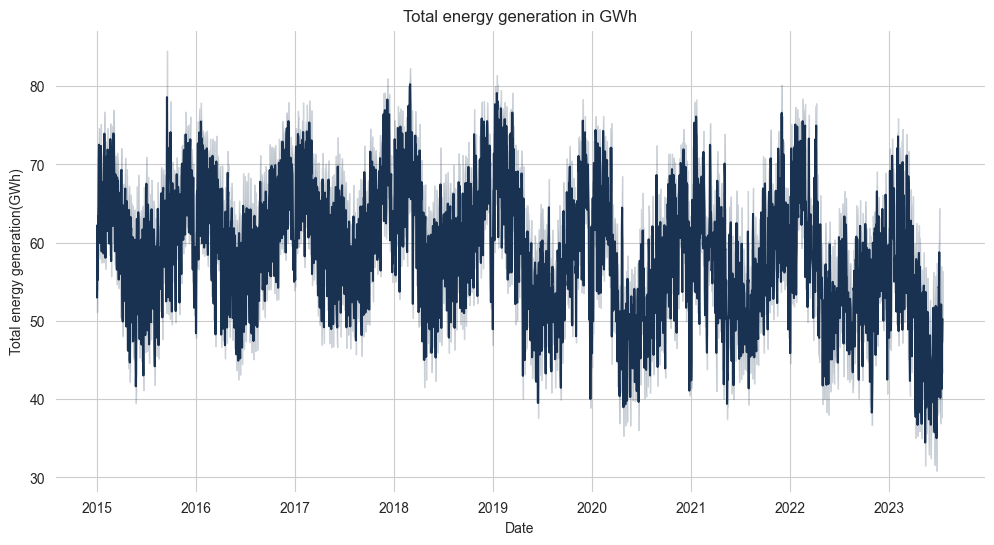

In [26]:
## Energy development over year (time)
fig, ax = plt.subplots()
sns.lineplot(x='Date', y=target, data=data_df, ax=ax)
ax.set(title=title_main, ylabel= ylable_target);

In [27]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    simple_lineplot(df=data_df, y=col, x="Date", time='Year')

In [28]:
data_df.columns

Index(['Area', 'Mtu', 'Biomass_gwh', 'Fossil_brown_coal_gwh',
       'Fossil_coal_derived_gas_gwh', 'Fossil_gas_gwh', 'Fossil_hard_coal_gwh',
       'Fossil_oil_gwh', 'Fossil_oil_shale_gwh', 'Fossil_peat_gwh',
       'Geothermal_gwh', 'Hydro_pumped_storage_aggregated_gwh',
       'Hydro_pumped_storage_consumption_gwh',
       'Hydro_run_of_river_and_poundage_gwh', 'Hydro_water_reservoir_gwh',
       'Marine_gwh', 'Nuclear_gwh', 'Other_gwh', 'Other_renewable_gwh',
       'Solar_gwh', 'Waste_gwh', 'Wind_offshore_gwh', 'Wind_onshore_gwh',
       'Date', 'Hour', 'Total_energy_generation_gwh', 'Solar/total_energy',
       'Diff_total_energy_and_solar_gwh', 'Total_other_renewable_gwh', 'Year',
       'Month', 'Day', 'Dayofyear'],
      dtype='object')

In [29]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot_no_group(df=data_df, y=col, x="Date", time='Year')

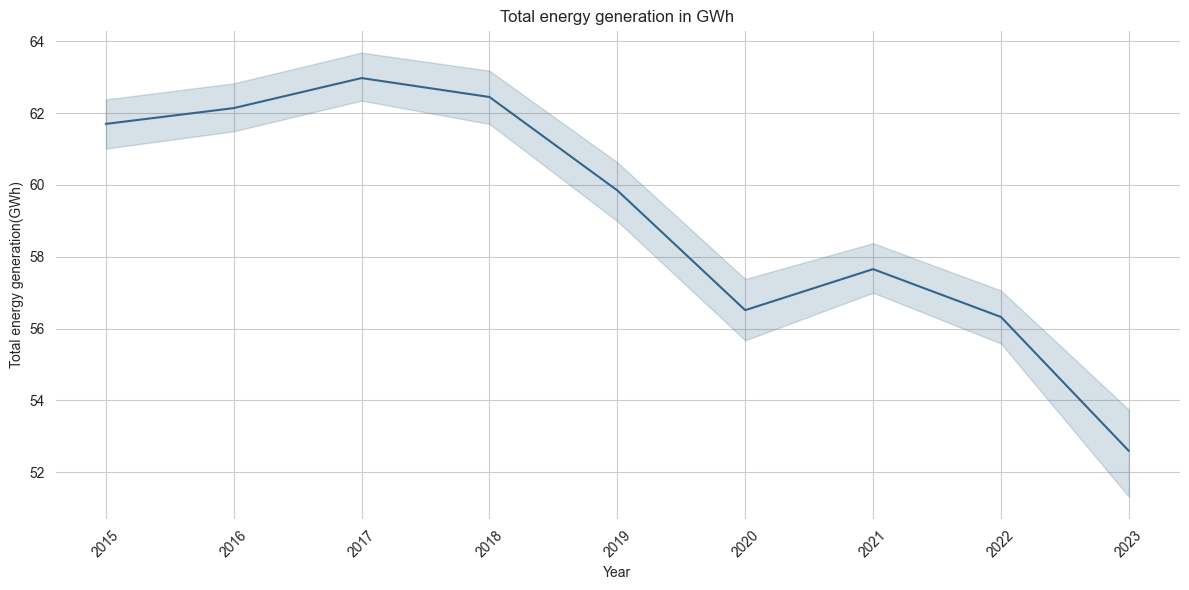

In [30]:
average_lineplot_no_group(df=data_df, y= target, x="Date", time='Year')

In [31]:
# Aggregate Energy_mwh or Solar_mwh by day
daily_data_df = data_df \
    .groupby(['Date', 'Year', 'Month', 'Day', 'Dayofyear', 'Hour'], as_index=False)\
    .agg({target: np.sum}) \
    .set_index('Date')

In [32]:
daily_data_df

,Year,Month,Day,Dayofyear,Hour,Total_energy_generation_gwh
Date,,,,,,
2015-01-01,2015,1,1,1,0,51.45925
2015-01-01,2015,1,1,1,1,49.98825
2015-01-01,2015,1,1,1,2,49.26525
2015-01-01,2015,1,1,1,3,48.53800
2015-01-01,2015,1,1,1,4,48.63000
...,...,...,...,...,...,...
2023-07-17,2023,7,17,198,18,55.58000
2023-07-17,2023,7,17,198,19,50.83350
2023-07-17,2023,7,17,198,20,46.67225


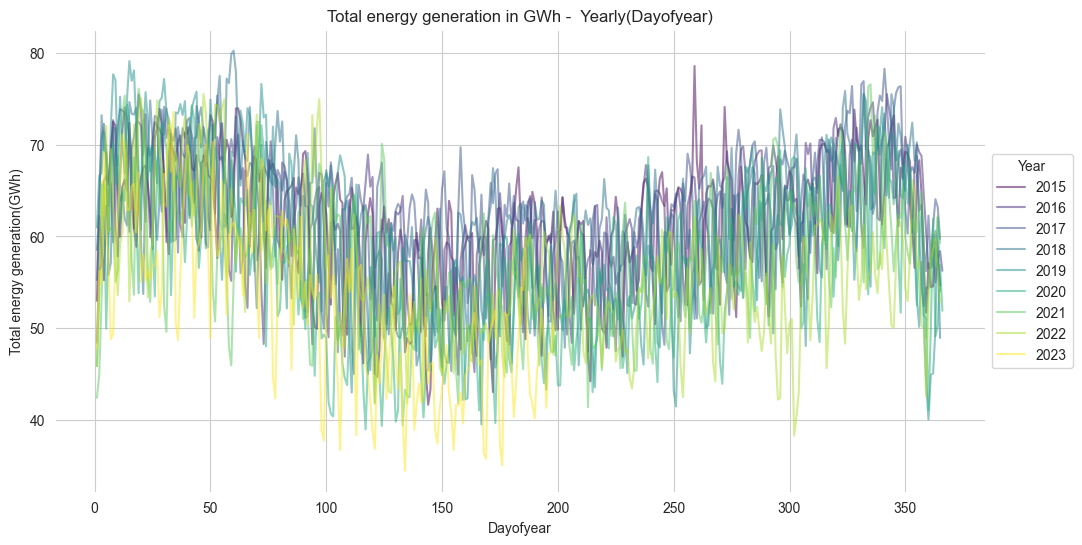

In [33]:
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=daily_data_df[['Year', 'Dayofyear', target]], index='Dayofyear', columns='Year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title= title_main +' '+'-'+' ' + ' ' +'Yearly(Dayofyear)', ylabel=ylable_target);
#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

In [34]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr = ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Total_other_renewable_gwh', 'Other_renewable_gwh', 'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh', 
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Dayofyear', group='Year')

In [36]:
# We would like to check the average renewable energy  targets by years
#ycol_aggr =  ['Total_energy_generation_gwh', 'Solar_gwh', 'Solar/total_energy','Diff_total_energy_and_solar_gwh',
#             'Wind_onshore_gwh','Wind_offshore_gwh','Waste_gwh','Solar_gwh','Other_renewable_gwh',  
#             'Marine_gwh','Hydro_run_of_river_and_poundage_gwh','Hydro_water_reservoir_gwh','Geothermal_gwh']
#for col in ycol_aggr:
#    average_lineplot(df=data_df, y=col, x='Date', time='Month', group='Year')

### Creating train and test sets
We will split our data and take the first part as our training set and the years after 2016 as a test set. Since we are dealing with a time series here we cannot split randomly as we are used to do. 

In [36]:
# Split data into train and test set
#window=365#*24
#df_arima = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_arima = df_arima.dropna()
#

#df_arima = data_df[target]
#train_test_split_ratio = int(len(df_arima)*0.8)
#train_data, test_data = df_arima[:train_test_split_ratio], df_arima[train_test_split_ratio:]

# Plotting the train and test set
#plt.figure(figsize=(10,6))
#plt.xlabel('Time')
#plt.ylabel(ylable_target)
#plt.plot(train_data, 'red', label='Train data')
#plt.plot(test_data, 'black', label='Test data')
#plt.legend()
#plt.xticks([])
#plt.xlim(pd.to_datetime("2015"),pd.to_datetime("2023"))

## Random forest  regression  (unscaled data)

RMSE: 7.773950657957735
MSE: 60.4343088323615
MAE: 6.4993042203068825
R2 Score: 0.49271227836203124


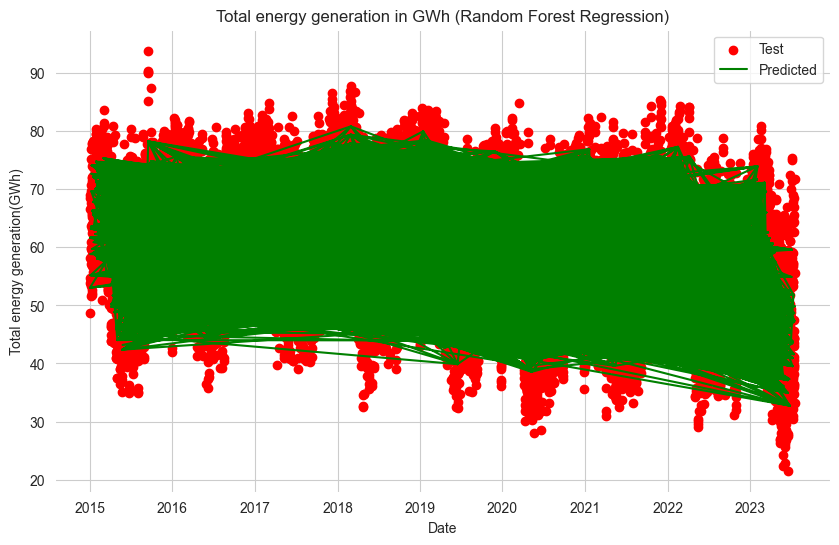

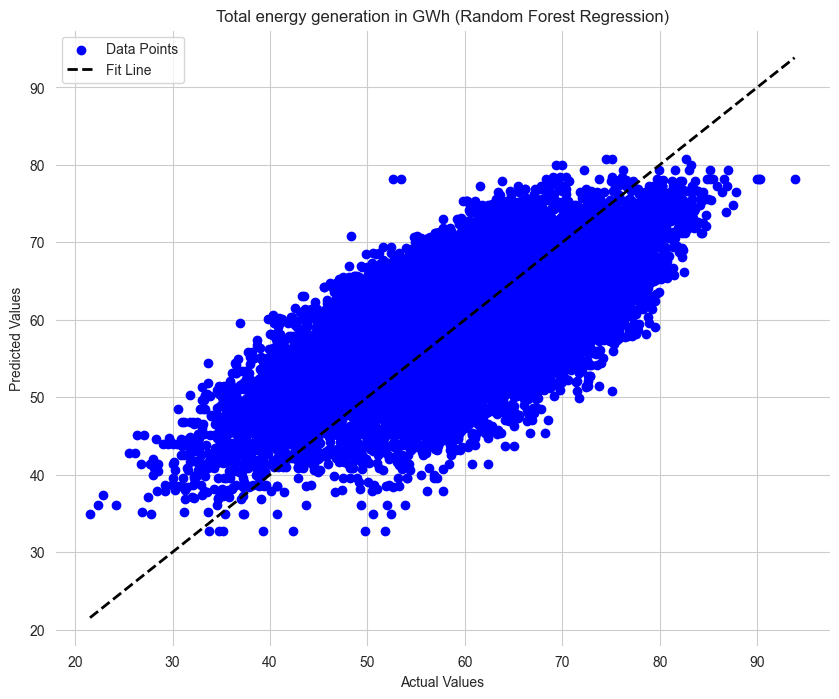

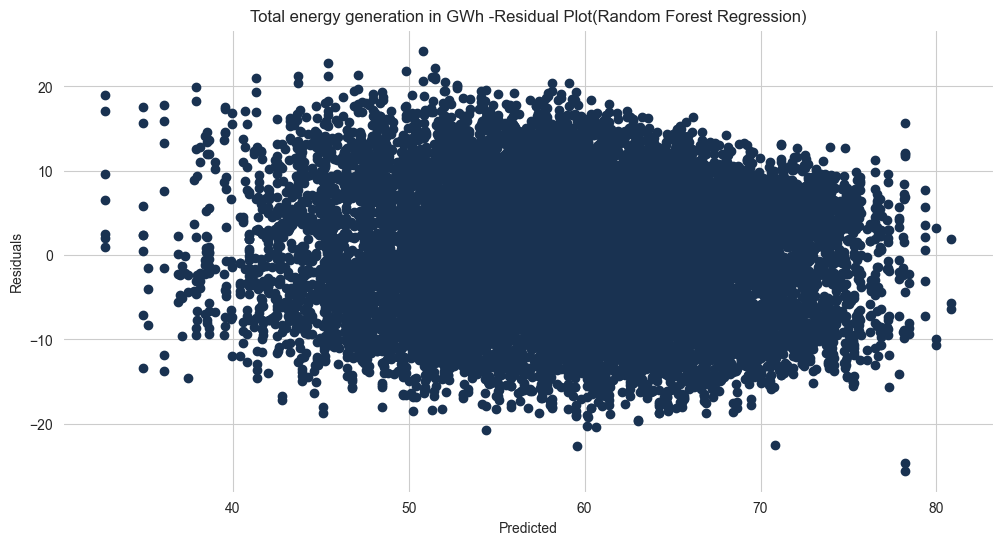

In [40]:
#df_c = data_df.copy()
#splitting the data into features and target
#window=365
#df_c[target] = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_c = df_c.dropna()

df_c = data_df.copy()
#splitting the data into features and target
#window=365
#df_c[target] = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_c = df_c.dropna()


# Converting date to datetime format
df_c['Date'] = pd.to_datetime(df_c['Date'])

# Extracting features and target
X = df_c[['Date']]
y = df_c[target]

# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#plt.figure(figsize=(10,6))
#plt.xlabel('Time')
#plt.ylabel(ylable_target)
#plt.plot(y_train, 'red', label='Train data')
#plt.plot(y_test, 'black', label='Test data')
#plt.legend()
#plt.xticks([])

# Fitting the model
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Making predictions on the test set
y_pred = rf_reg.predict(X_test)

# Computing the error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

# Plotting the results
plt.figure(figsize=(10, 6))
#plt.scatter(X_train, y_train, label='Train', color='blue')
plt.scatter(X_test, y_test, label='Test', color='red')
plt.plot(X_test, y_pred, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel(ylable_target)
plt.title(title_main  +' ' + '(Random Forest Regression)')
plt.legend()
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, label='Data Points', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main  +' ' +  '(Random Forest Regression)')
plt.legend()
plt.show()

residuals = y_test - y_pred
#plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals)
#plt.plot([y_pred.min(), y_pred.max()], [-20, 20], 'k--', lw=2, label='Fit Line')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title(title_main  +' ' +'-' +'Residual Plot' +  '(Random Forest Regression)')
plt.show()

In [138]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
#print(classification_report(y_test, y_pred)) 
# Plotting the train and test set
#plt.figure(figsize=(10,6))
#plt.xlabel('Time')
#plt.ylabel(ylable_target)
#plt.plot(y_train, 'red', label='Train data')
#plt.plot(y_test, 'black', label='Test data')
#plt.legend()
#plt.xticks([])

X_train: (59903, 1)
y_train: (59903,)
X_test: (14976, 1)
y_test: (14976,)


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_23645/1812047045.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Year'] = X['Date'].dt.year
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_23645/1812047045.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Month'] = X['Date'].dt.month
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_23645/1812047045.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

RMSE: 7.773950657957735
MSE: 60.4343088323615
MAE: 6.4993042203068825
R2 Score: 0.49271227836203124


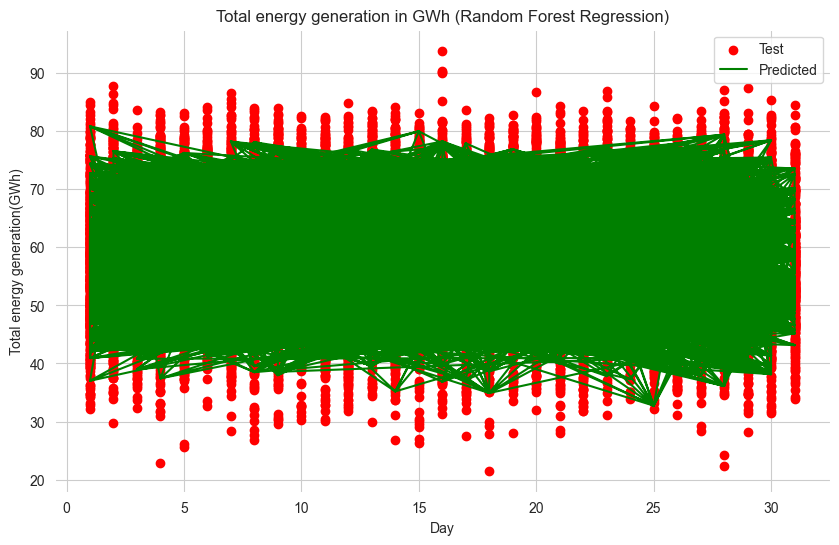

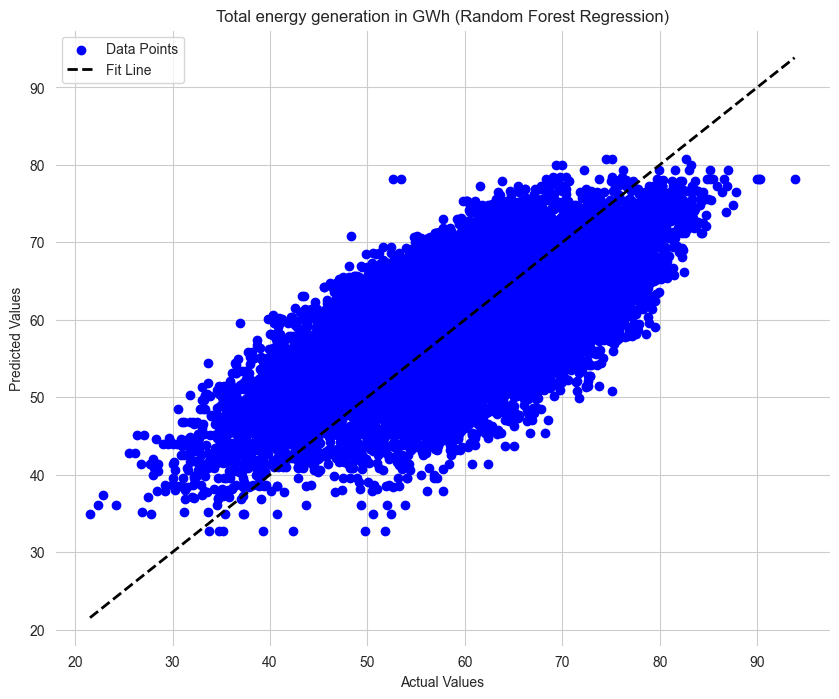

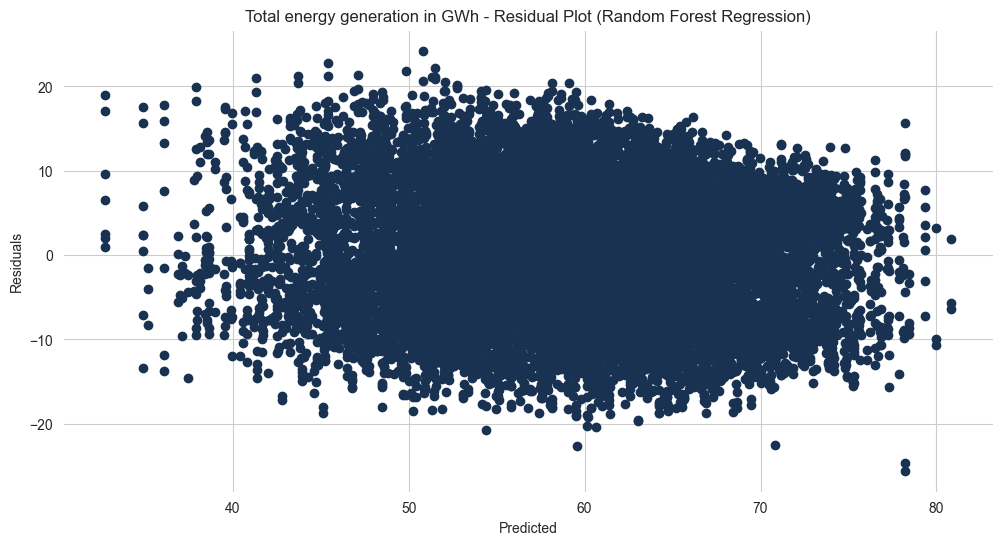

In [47]:
# Assuming you have defined these variables somewhere in your code
# target = 'Your_Target_Column_Name'
# ylable_target = 'Your_Y_Label'
# title_main = 'Your_Title'

# Assuming your data_df contains the relevant columns 'Date' and 'Your_Target_Column_Name'

# Make a copy of the data
df_c = data_df.copy()

# Convert date to datetime format
df_c['Date'] = pd.to_datetime(df_c['Date'], format='%d-%m-%y')

# Extracting features and target
X = df_c[['Date']]
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month
X['Day'] = X['Date'].dt.day
X = X.drop(columns=['Date'])  # Drop the original datetime column

y = df_c[target]

# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fitting the model (Random Forest Regressor)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Making predictions on the test set
y_pred = rf_reg.predict(X_test)

# Computing the error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.scatter(X_test['Day'], y_test, label='Test', color='red')  # Assuming Year is used as an input feature
plt.plot(X_test['Day'], y_pred, label='Predicted', color='green')  # Assuming Year is used as an input feature
plt.xlabel('Day')  # Assuming Year is used as an input feature
plt.ylabel(ylable_target)
plt.title(title_main + ' (Random Forest Regression)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, label='Data Points', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (Random Forest Regression)')
plt.legend()
plt.show()

residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title(title_main + ' - Residual Plot (Random Forest Regression)')
plt.show()


RMSE: 9.729975123313258
MSE: 94.67241590029485
MAE: 8.01430491704524
R2 Score: 0.2053163990467345


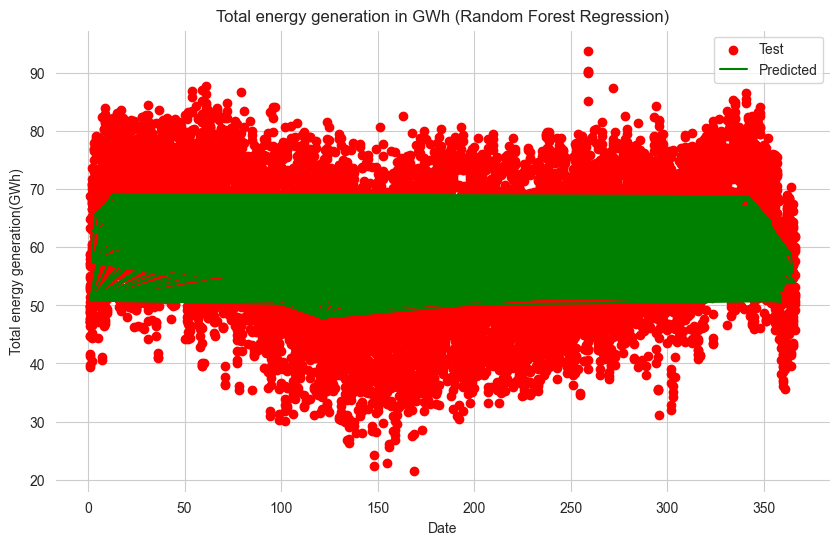

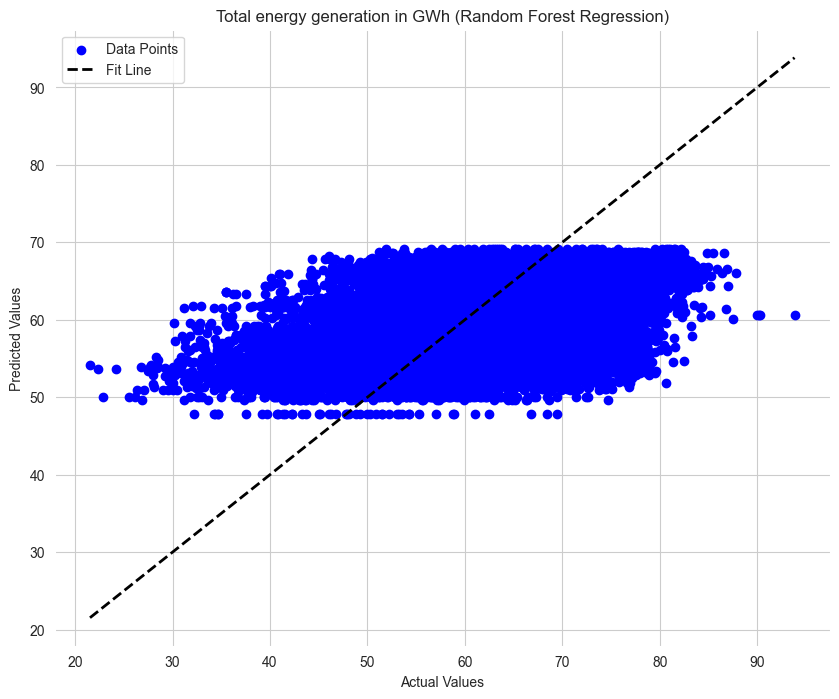

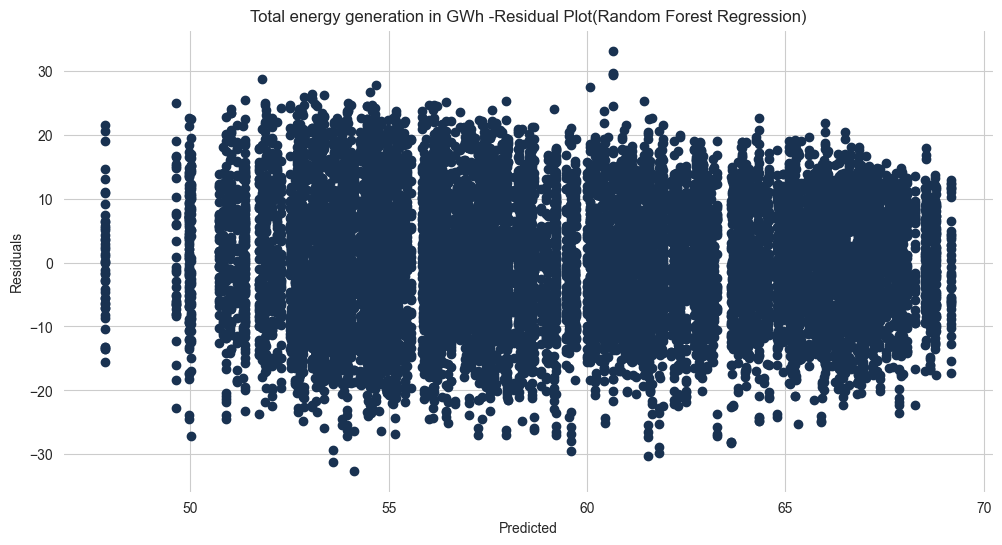

In [39]:
#df_c = data_df.copy()
#splitting the data into features and target
#window=365
#df_c[target] = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_c = df_c.dropna()

df_c = data_df.copy()
#splitting the data into features and target
#window=365
#df_c[target] = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_c = df_c.dropna()


# Converting date to datetime format
#df_c['Dayofyear'] = pd.to_datetime(df_c['Dayofyear'])

# Extracting features and target
X = df_c[['Dayofyear']]
y = df_c[target]

# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#plt.figure(figsize=(10,6))
#plt.xlabel('Time')
#plt.ylabel(ylable_target)
#plt.plot(y_train, 'red', label='Train data')
#plt.plot(y_test, 'black', label='Test data')
#plt.legend()
#plt.xticks([])

# Fitting the model
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Making predictions on the test set
y_pred = rf_reg.predict(X_test)

# Computing the error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

# Plotting the results
plt.figure(figsize=(10, 6))
#plt.scatter(X_train, y_train, label='Train', color='blue')
plt.scatter(X_test, y_test, label='Test', color='red')
plt.plot(X_test, y_pred, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel(ylable_target)
plt.title(title_main  +' ' + '(Random Forest Regression)')
plt.legend()
plt.show()

#plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, label='Data Points', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main  +' ' +  '(Random Forest Regression)')
plt.legend()
plt.show()

residuals = y_test - y_pred
#plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals)
#plt.plot([y_pred.min(), y_pred.max()], [-20, 20], 'k--', lw=2, label='Fit Line')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title(title_main  +' ' +'-' +'Residual Plot' +  '(Random Forest Regression)')
plt.show()

 ## RandomizedSearchCV:

In [ ]:
def perform_randomized_search(X, y):
    # Create a parameter grid for hyperparameter tuning
    param_dist = {
        'n_estimators': [50, 100, 200, 300],  # Number of trees in the forest
        'max_features': ['auto', 'sqrt'],  # Number of features to consider at every split
        'max_depth': [None, 10, 20, 30],  # Maximum depth of the tree
        'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split an internal node
        'min_samples_leaf': [1, 2, 4]  # Minimum number of samples required to be at a leaf node
    }

    # Create a base random forest regressor
    rf_reg = RandomForestRegressor(random_state=42)

    # Initialize RandomizedSearchCV
    rf_random = RandomizedSearchCV(estimator=rf_reg, param_distributions=param_dist, n_iter=100,
                                   cv=5, verbose=2, random_state=42, n_jobs=-1)

    # Fit the RandomizedSearchCV on the data
    rf_random.fit(X, y)

    # Get the best hyperparameters
    best_params = rf_random.best_params_

    return best_params


#### Code for RandomizedSearchCV

In [ ]:
df_c = data_df.copy()
# Convert 'Date' to datetime format (if it is not already in datetime format)
df_c['Date'] = pd.to_datetime(df_c['Date'])

# Extracting features and target
X = df_c[['Date']]
y = df_c[target]

# Perform RandomizedSearchCV for hyperparameter tuning
best_params = perform_randomized_search(X, y)

# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fitting the model with the best hyperparameters from RandomizedSearchCV
rf_reg = RandomForestRegressor(random_state=42, **best_params)
rf_reg.fit(X_train, y_train)

# Making predictions on the test set
y_pred = rf_reg.predict(X_test)

# Computing the error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best Hyperparameters:", best_params)
print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.scatter(X_test, y_test, label='Test', color='red')
plt.plot(X_test, y_pred, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel(ylable_target)
plt.title(title_main + ' (Random Forest Regression)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, label='Data Points', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (Random Forest Regression)')
plt.legend()
plt.show()

residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title(title_main + ' - Residual Plot (Random Forest Regression)')
plt.show()


## Random Forest Optimization through Random Search

In order to maximize the performance of the random forest, we can perform a random search for better hyperparameters. This will randomly select combinations of hyperparameters from a grid, evaluate them using cross validation on the training data, and return the values that perform the best. 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Hyperparameter grid
param_grid = {
    'n_estimators': np.linspace(10, 200).astype(int),
    'max_depth': [None] + list(np.linspace(3, 20).astype(int)),
    'max_features': ['auto', 'sqrt', None] + list(np.arange(0.5, 1, 0.1)),
    'max_leaf_nodes': [None] + list(np.linspace(10, 50, 500).astype(int)),
    'min_samples_split': [2, 5, 10],
    'bootstrap': [True, False]
}

# Estimator for use in random search
estimator = RandomForestClassifier(random_state = RSEED)

# Create the random search model
rs = RandomizedSearchCV(estimator, param_grid, n_jobs = -1, 
                        scoring = 'roc_auc', cv = 3, 
                        n_iter = 10, verbose = 5, random_state=RSEED)

# Fit 
rs.fit(train, train_labels)

In [ ]:
rs.best_params_

We can see that the best hyperparameter values are not the defaults. This shows the importance of tuning a model for a specific dataset. Each dataset will have different characteristics, and the model that does best on one dataset will not necessarily do the best across all datasets. 

## Use Best Model

Now we can take the best model (it has already been trained) and evaluate it. Hopefully it does better than the stock Random Forest.

In [ ]:
best_model = rs.best_estimator_

In [ ]:
train_rf_predictions = best_model.predict(train)
train_rf_probs = best_model.predict_proba(train)[:, 1]

rf_predictions = best_model.predict(test)
rf_probs = best_model.predict_proba(test)[:, 1]

In [ ]:
n_nodes = []
max_depths = []

for ind_tree in best_model.estimators_:
    n_nodes.append(ind_tree.tree_.node_count)
    max_depths.append(ind_tree.tree_.max_depth)
    
print(f'Average number of nodes {int(np.mean(n_nodes))}')
print(f'Average maximum depth {int(np.mean(max_depths))}')

The best maximum depth is not unlimited as we see above! This indicates that restricting the maximum depth of the individual decision trees can improve the cross validation performance of the random forest. 

In [ ]:
evaluate_model(rf_predictions, rf_probs, train_rf_predictions, train_rf_probs)

In [ ]:
train_rf_predictions = model.predict(train)
train_rf_probs = model.predict_proba(train)[:, 1]

rf_predictions = model.predict(test)
rf_probs = model.predict_proba(test)[:, 1]

In [ ]:
# Defining function which calculates residuals and plots them
def get_residuals(dataset, color):
    # store true y values
    obs_values = anscombe[anscombe.dataset==dataset].y 
    # store predicted y values
    pred_values = get_summarystats(dataset)[0] * anscombe[anscombe.dataset==dataset].x + get_summarystats(dataset)[1] 
    # calculate residuals
    residuals = obs_values - pred_values
    # plot residuals
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(anscombe[anscombe.dataset==dataset].x, residuals, color=color)
    ax.set_ylabel("Residuals")
    ax.set_xlabel("x")
    fig.suptitle('Residual Scatter Plot')
    plt.show()

In [ ]:
# Define same color palette as above
color = sns.color_palette('muted')

# Use defined function to plot residuals for all datasets
for dataset, c in zip('I II III IV'.split(), color):
    get_residuals(dataset, c) 

## XGBoost regressor 

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_23645/2718969786.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Year'] = X['Date'].dt.year
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_23645/2718969786.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Month'] = X['Date'].dt.month
/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_23645/2718969786.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

RMSE: 8.229218136599334
MSE: 67.72003113973543
MAE: 6.865251683053806
R2 Score: 0.431555668131792


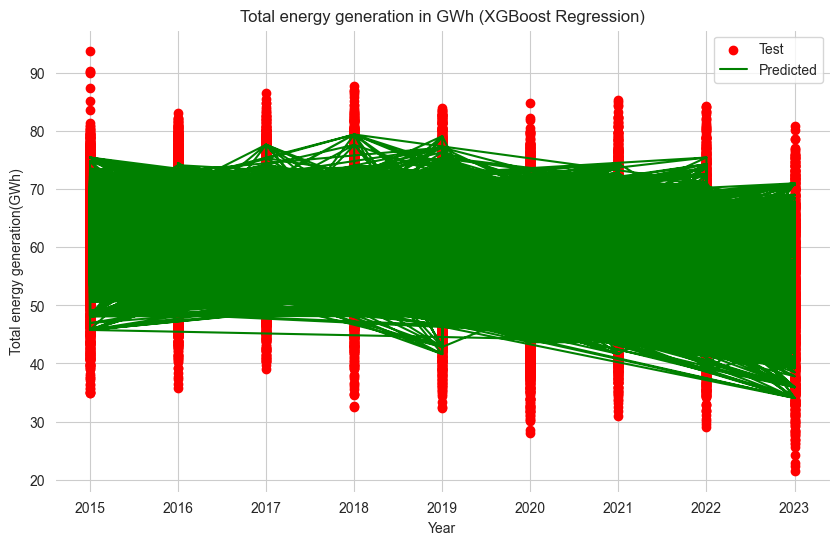

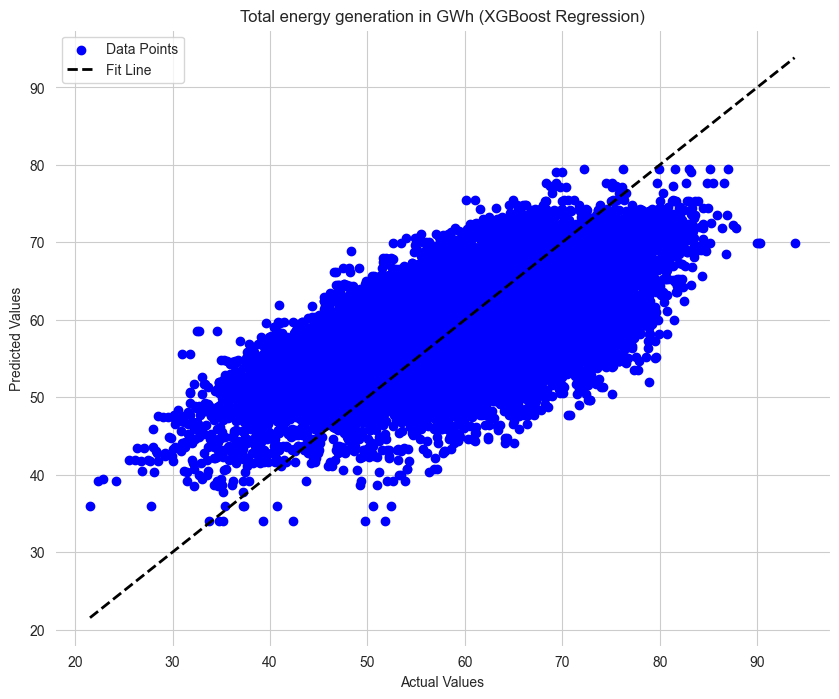

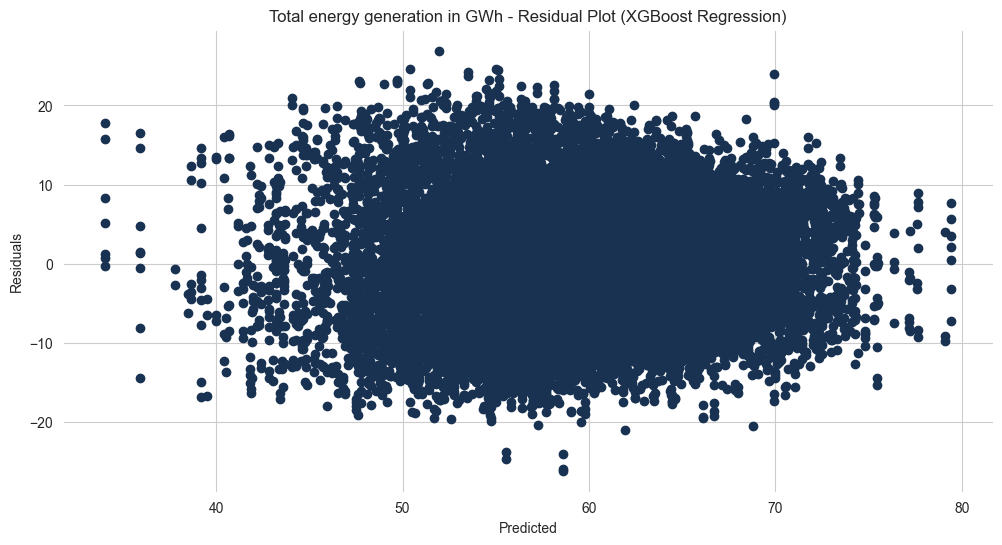

In [45]:
# Assuming you have defined these variables somewhere in your code
# target = 'Your_Target_Column_Name'
# ylable_target = 'Your_Y_Label'
# title_main = 'Your_Title'

# Assuming your data_df contains the relevant columns 'Date' and 'Your_Target_Column_Name'

# Make a copy of the data
df_c = data_df.copy()

# Convert date to datetime format
#df_c['Date'] = pd.to_datetime(df_c['Date'], format='%d-%m-%y')

# Extracting features and target
X = df_c[['Date']]
X['Year'] = X['Date'].dt.year
X['Month'] = X['Date'].dt.month
X['Day'] = X['Date'].dt.day
X = X.drop(columns=['Date'])  # Drop the original datetime column

y = df_c[target]

# Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fitting the model (XGBoost Regressor)
xgb_reg = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_reg.fit(X_train, y_train)

# Making predictions on the test set
y_pred = xgb_reg.predict(X_test)

# Computing the error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.scatter(X_test['Year'], y_test, label='Test', color='red')  # Assuming Year is used as an input feature
plt.plot(X_test['Year'], y_pred, label='Predicted', color='green')  # Assuming Year is used as an input feature
plt.xlabel('Year')  # Assuming Year is used as an input feature
plt.ylabel(ylable_target)
plt.title(title_main + ' (XGBoost Regression)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, label='Data Points', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (XGBoost Regression)')
plt.legend()
plt.show()

residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title(title_main + ' - Residual Plot (XGBoost Regression)')
plt.show()


In [44]:
X.columns

Index(['Year', 'Month', 'Day'], dtype='object')

## Linear Regression Method

RMSE: 7.543284907777742
MSE: 56.901147199907456
MAE: 5.985526925029698
R2 Score: -0.5023470018788687


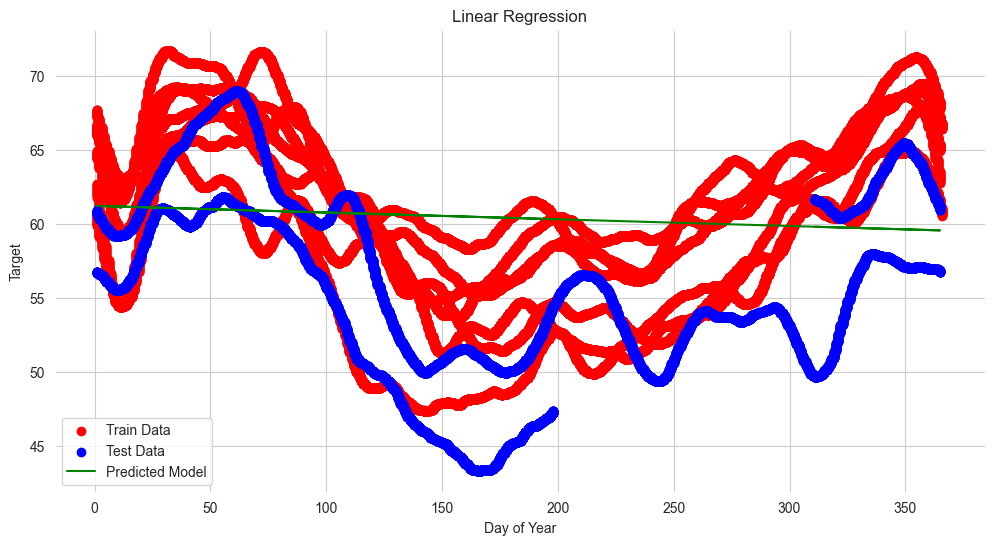

In [188]:
df_c = data_df.copy()
# Converting date to datetime format
df_c['Date'] = pd.to_datetime(df_c['Date'])

# Extracting target
y = df_c[target]

# Splitting the data into train and test sets (assuming a split index of 80%)
train_size = int(0.8 * len(y))
y_train, y_test = y[:train_size], y[train_size:]

# Creating a numeric representation of the datetime for linear regression
X_train = pd.to_numeric(df_c['Date'][:train_size])
X_test = pd.to_numeric(df_c['Date'][train_size:])

# Reshaping the data for Linear Regression
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

# Fitting the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Making predictions on the test set
y_pred = lr_model.predict(X_test)

# Computing the error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(df_c['Date'], y, label='Data', color='blue')
plt.plot(df_c['Date'][train_size:], y_pred, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel(ylable_target)
plt.title(title_main + ' (Linear Regression)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, label='Data Points', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (Linear Regression)')
plt.legend()
plt.show()

# Plotting the residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title(title_main + ' - Residual Plot (Linear Regression)')
plt.show()


RMSE: 10.90
MSE: 118.77
MAE: 8.95
R2 Score: 0.00


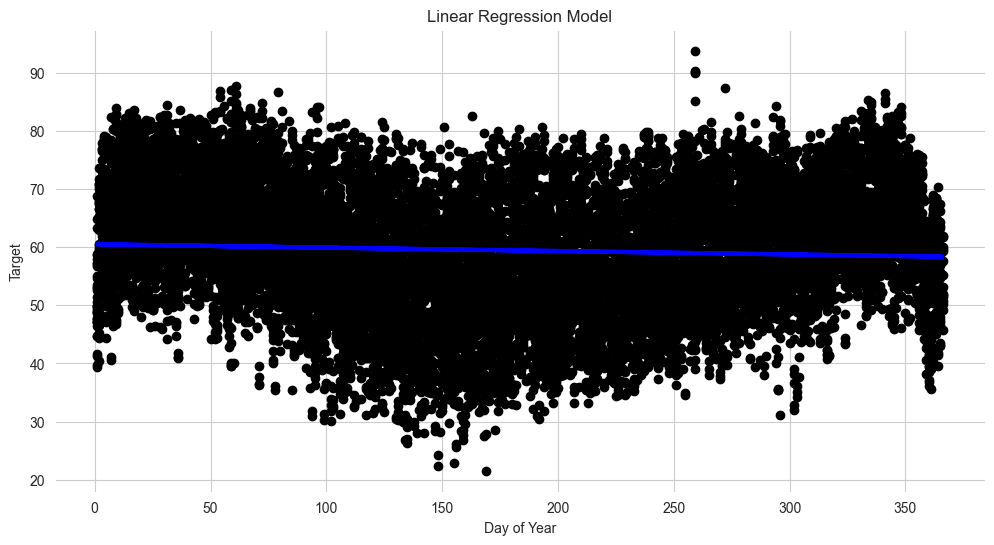

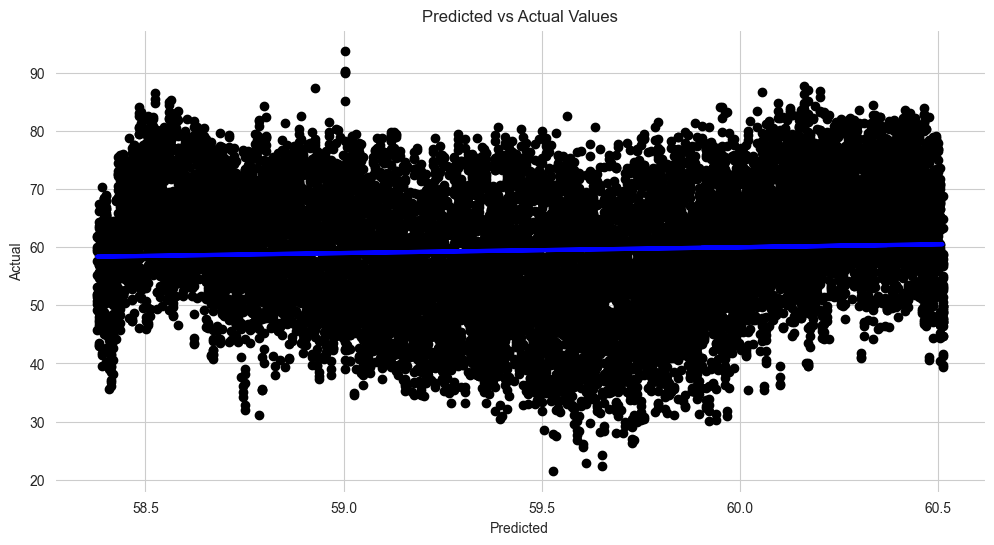

In [183]:

# Split the data into training and testing sets
X = data_df['Dayofyear']
y = data_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model to the training data
regressor = LinearRegression()  
regressor.fit(X_train.values.reshape(-1, 1), y_train)

# Make predictions using the testing set
y_pred = regressor.predict(X_test.values.reshape(-1, 1))

# Compute and print RMSE, MSE, MAE, and R2 score matrices
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("RMSE: %.2f" % rmse)
print("MSE: %.2f" % mse)
print("MAE: %.2f" % mae)
print("R2 Score: %.2f" % r2)

# Plot the results
plt.scatter(X_test, y_test,  color='black')
plt.plot(X_test, y_pred, color='blue', linewidth=3)
plt.title('Linear Regression Model')
plt.xlabel('Day of Year')
plt.ylabel('Target')
plt.show()

# Plot the predicted vs actual values
plt.scatter(y_pred, y_test,  color='black')
plt.plot(y_pred, y_pred, color='blue', linewidth=3)
plt.title('Predicted vs Actual Values')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

RMSE: 3.611854890428194
MSE: 13.045495749510062
MAE: 3.0239854417205625
R2 Score: 0.6152554954699543


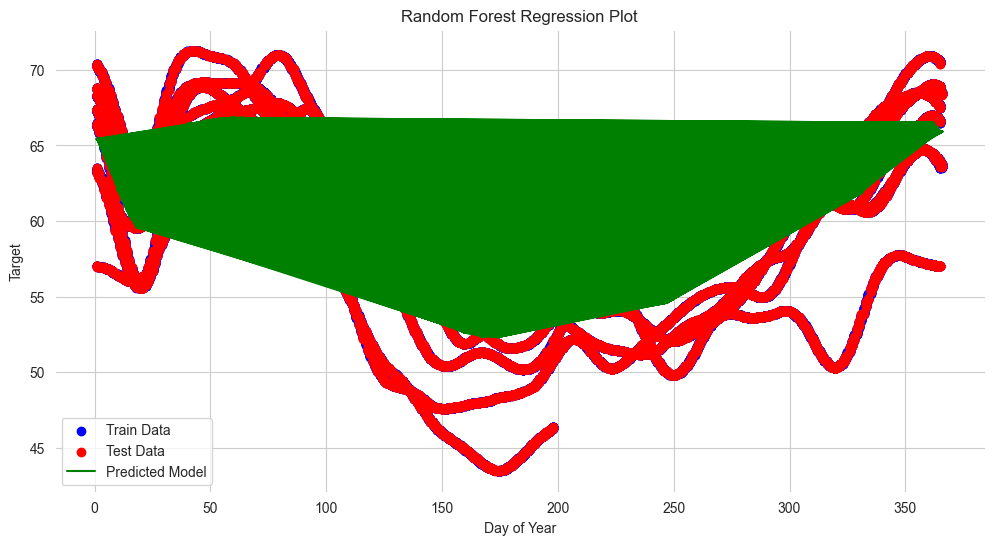

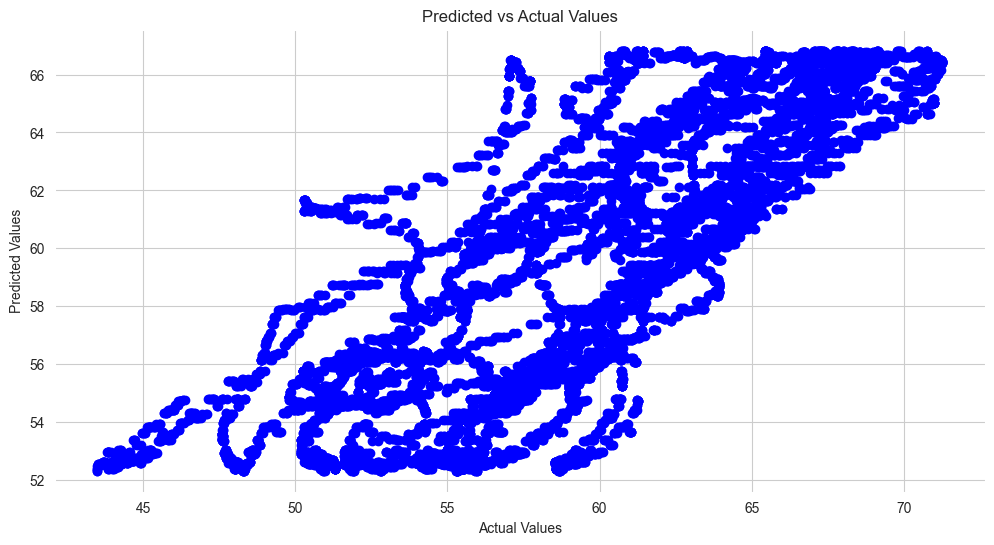

In [ ]:
#splitting the data into features and target
window=365
data_df[target] = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
data_df = data_df.dropna()

X = data_df['Dayofyear']
y = data_df[target]

#splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#fitting the model
rf_reg = RandomForestRegressor()
rf_reg.fit(X_train.values.reshape(-1, 1), y_train)

#predicting on the test set
y_pred = rf_reg.predict(X_test.values.reshape(-1, 1))

#computing the metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

#printing the metrics
print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

#plotting the results
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.plot(X_test, y_pred, color='green', label='Predicted Model')
plt.title('Random Forest Regression Plot')
plt.xlabel('Day of Year')
plt.ylabel('Target')
plt.legend()
plt.show()

#plotting the predicted vs actual values
plt.scatter(y_test, y_pred, color='blue')
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.show()

## SRIMA model

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.96276D+00    |proj g|=  2.17456D-01


 This problem is unconstrained.



At iterate    5    f=  1.75083D+00    |proj g|=  2.95895D-02

At iterate   10    f=  1.72570D+00    |proj g|=  4.58086D-02

At iterate   15    f=  1.70617D+00    |proj g|=  4.77233D-02

At iterate   20    f=  1.69875D+00    |proj g|=  7.10212D-04

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     23     28      1     0     0   1.220D-06   1.699D+00
  F =   1.6987510193215698     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
RMSE: 492.6727655386773
MSE: 242726.45390352848
MAE: 428.8713675499306
R2 Score: -1893.4168645258646


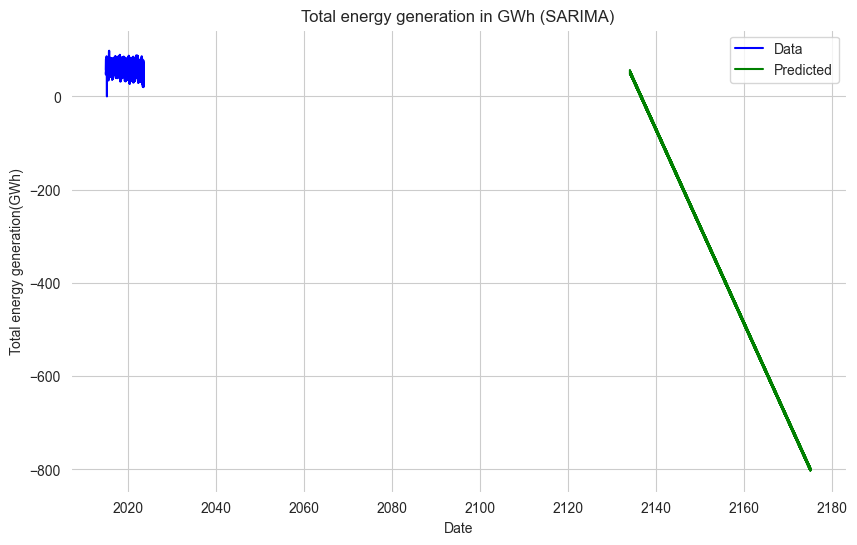

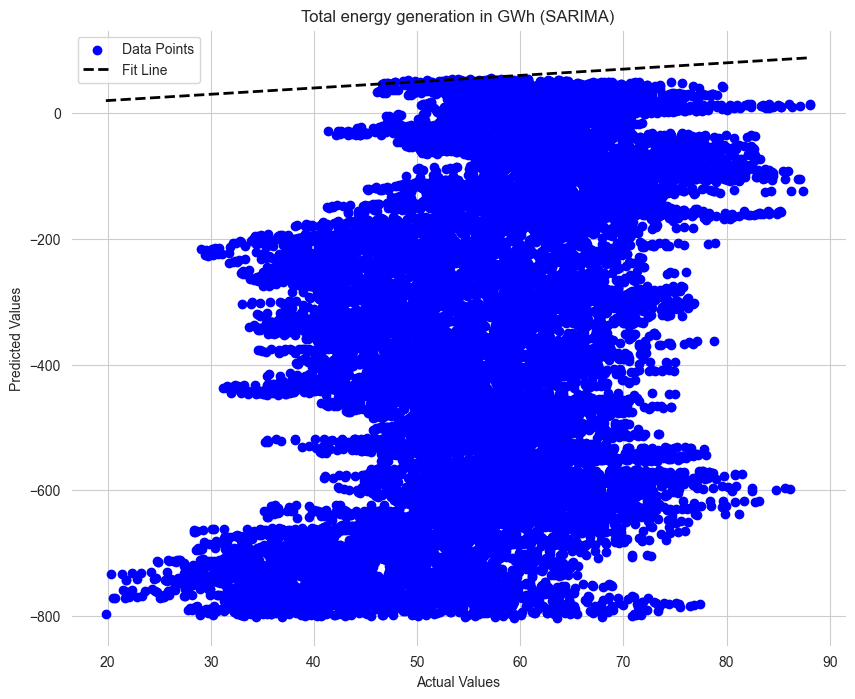

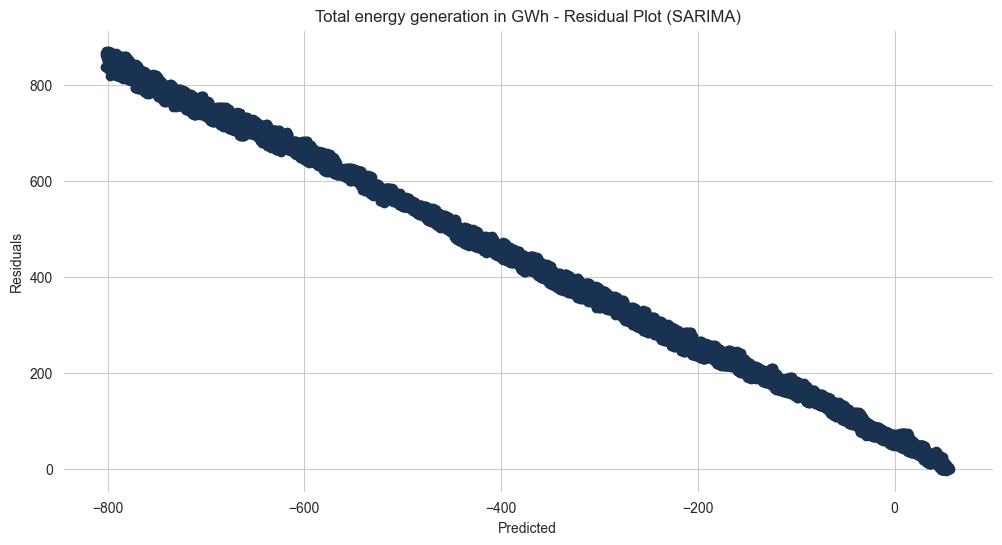

In [140]:
## SRIMA model
df_c = data_df.copy()
#window=365
#df_c[target] = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_c = df_c.dropna()
# Assuming you have already defined the target variable 'target' and other variables like df_c, ylable_target, title_main
# Converting date to datetime format
df_c['Date'] = pd.to_datetime(df_c['Date'])

# Extracting target
y = df_c[target]

# Splitting the data into train and test sets (assuming a split index of 80%)
train_size = int(0.8 * len(y))
y_train, y_test = y[:train_size], y[train_size:]

# Fitting the SARIMA model
order = (1, 1, 1)  # ARIMA order (p, d, q)
seasonal_order = (1, 1, 1, 12)  # Seasonal order (P, D, Q, seasonal_period)
sarima_model = SARIMAX(y_train, order=order, seasonal_order=seasonal_order)
sarima_fit = sarima_model.fit()

# Making predictions on the test set
y_pred = sarima_fit.forecast(len(y_test))

# Computing the error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

# Plotting the results
plt.figure(figsize=(10, 6))
#plt.plot(df_c['Date'], y, label='Data', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel(ylable_target)
plt.title(title_main + ' (SARIMA)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, label='Data Points', color='blue')
#plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (SARIMA)')
plt.legend()
plt.show()

# Plotting the residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title(title_main + ' - Residual Plot (SARIMA)')
plt.show()



In [141]:
## SRIMA model
df_c = data_df.copy()
#window=365
#df_c[target] = data_df[target].rolling(window).mean() # or #df_arima = data_df[target].rolling(window=365*24,center=True).mean()
#df_c = df_c.dropna()
# Assuming you have already defined the target variable 'target' and other variables like df_c, ylable_target, title_main
# Converting date to datetime format
df_c['Date'] = pd.to_datetime(df_c['Date'])

# Extracting target
y = df_c[target]

# Splitting the data into train and test sets (assuming a split index of 80%)
train_size = int(0.8 * len(y))
y_train, y_test = y[:train_size], y[train_size:]

# Fitting the SARIMA model
order = (1, 1, 1)  # ARIMA order (p, d, q)
seasonal_order = (1, 1, 1, 24)  # Seasonal order (P, D, Q, seasonal_period)
sarima_model = SARIMAX(y_train, order=order, seasonal_order=seasonal_order)
sarima_fit = sarima_model.fit()

# Making predictions on the test set
y_pred = sarima_fit.forecast(len(y_test))

# Computing the error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(df_c['Date'], y, label='Data', color='blue')
plt.plot(y_test.index, y_pred, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel(ylable_target)
plt.title(title_main + ' (SARIMA)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, label='Data Points', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (SARIMA)')
plt.legend()
plt.show()

# Plotting the residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title(title_main + ' - Residual Plot (SARIMA)')
plt.show()



### ARIMA Model

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


RMSE: 11.393514696435298
MSE: 129.81217713788712
MAE: 9.290567858382577
R2 Score: -0.013150291762480837


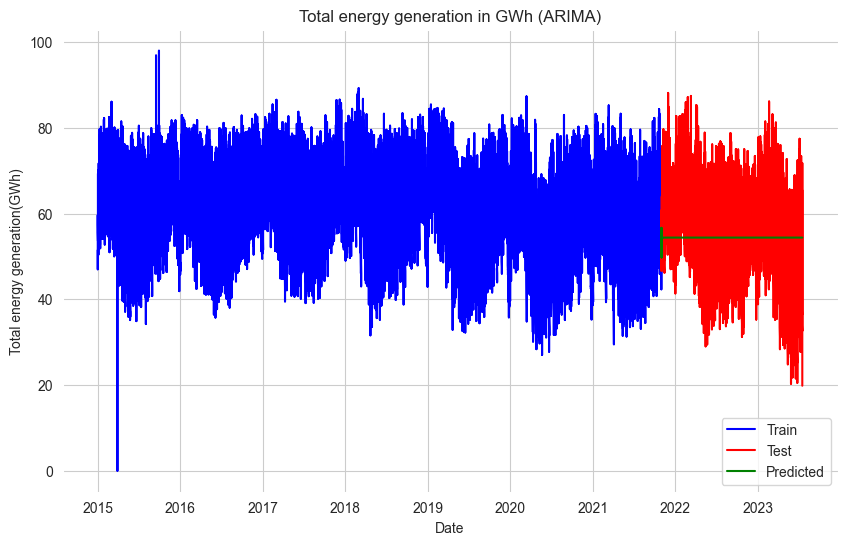

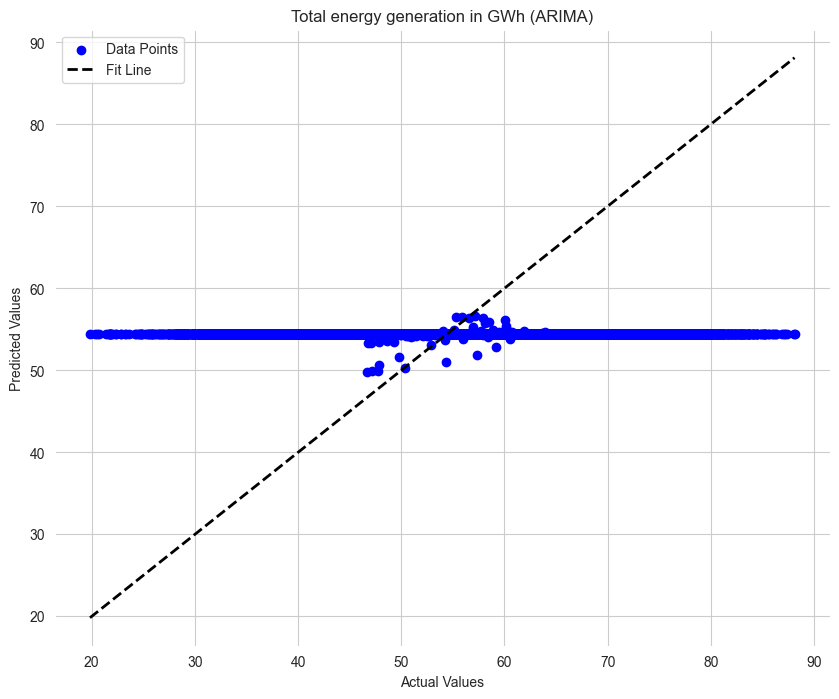

TypeError: '<' not supported between instances of 'Timestamp' and 'int'

In [49]:
# Assuming you have already loaded the data into the 'data_df' DataFrame
# and specified the 'target' column name, similar to your initial code.

# Copying the DataFrame and converting 'Date' to datetime format
df_c = data_df.copy()
df_c['Date'] = pd.to_datetime(df_c['Date'])

# Setting 'Date' as the index for time series data (if not already done)
df_c.set_index('Date', inplace=True)

# Splitting the data into train and test sets
train_size = int(len(df_c) * 0.8)
train, test = df_c[:train_size], df_c[train_size:]

# Finding the best ARIMA parameters using auto_arima
stepwise_fit = auto_arima(train[target], seasonal=False, error_action='ignore', suppress_warnings=True)

# Fitting the ARIMA model with the best parameters
arima_model = stepwise_fit.fit(train[target])

# Making predictions on the test set
y_pred = arima_model.predict(n_periods=len(test))

# Computing the error metrics
rmse = np.sqrt(mean_squared_error(test[target], y_pred))
mse = mean_squared_error(test[target], y_pred)
mae = mean_absolute_error(test[target], y_pred)
r2 = r2_score(test[target], y_pred)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)

# Plotting the results
plt.figure(figsize=(10, 6))
plt.plot(train.index, train[target], label='Train', color='blue')
plt.plot(test.index, test[target], label='Test', color='red')
plt.plot(test.index, y_pred, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel(ylable_target)
plt.title(title_main + ' (ARIMA)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(test[target], y_pred, label='Data Points', color='blue')
plt.plot([test[target].min(), test[target].max()], [test[target].min(), test[target].max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (ARIMA)')
plt.legend()
plt.show()

# Plotting the residuals
residuals = test[target] - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title(title_main + ' - Residual Plot (ARIMA)')
plt.show()


In [60]:
from statsmodels.tsa.stattools import adfuller
!pip install pmdarima --quiet
import pmdarima as pm

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


RMSE: 28.118151596432515
MSE: 790.6304491999605
MAE: 25.024410156757547
R2 Score: -5.170665094326136


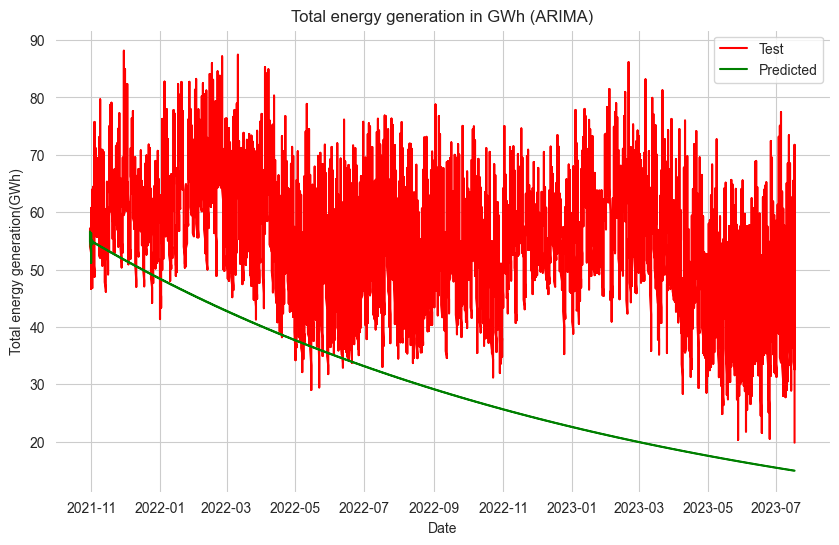

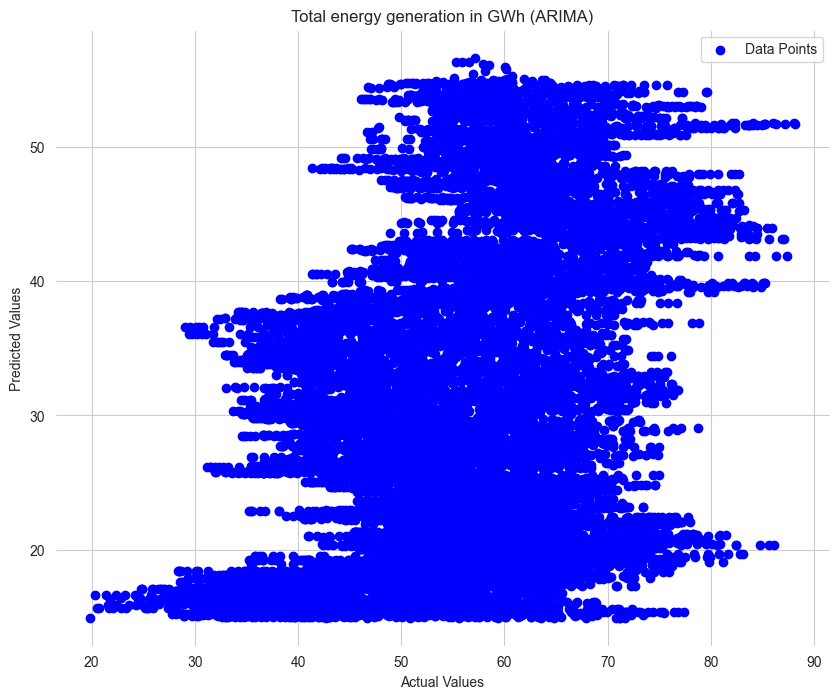

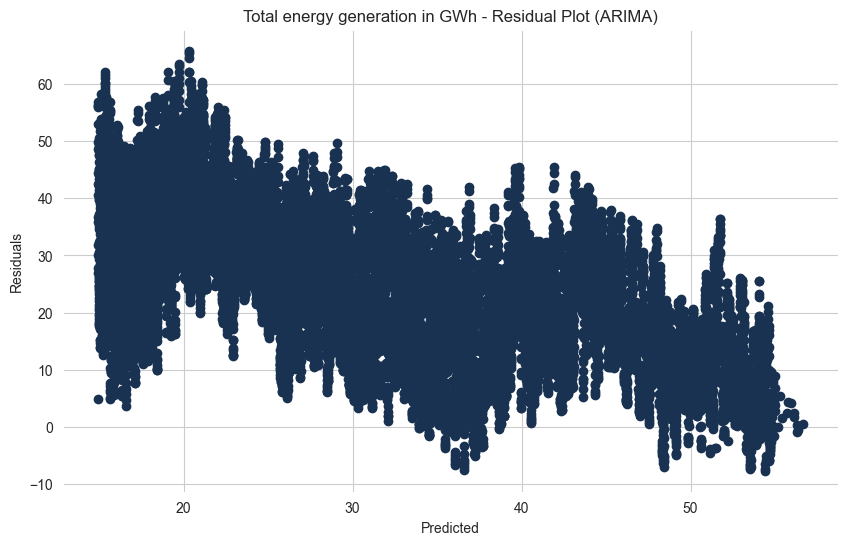

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                59903
Model:               SARIMAX(3, 0, 2)   Log Likelihood             -106628.817
Date:                Sat, 29 Jul 2023   AIC                         213269.635
Time:                        21:46:45   BIC                         213323.638
Sample:                             0   HQIC                        213286.410
                              - 59903                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          2.7612      0.002   1240.949      0.000       2.757       2.766
ar.L2         -2.5971      0.004   -587.657      0.000      -2.606      -2.588
ar.L3          0.8358      0.002    366.201      0.0

NameError: name 'forecast' is not defined

In [39]:
# Assuming you have already loaded the data into the 'data_df' DataFrame
# and specified the 'target' column name, similar to your initial code.

# Copying the DataFrame and converting 'Date' to datetime format
df_c = data_df.copy()
df_c['Date'] = pd.to_datetime(df_c['Date'])

# Setting 'Date' as the index for time series data (if not already done)
df_c.set_index('Date', inplace=True)

# Splitting the data into train and test sets
train_size = int(len(df_c) * 0.8)
train, test = df_c[:train_size], df_c[train_size:]

# Finding the best ARIMA parameters using auto_arima
#stepwise_fit = auto_arima(train[target], seasonal=False, error_action='ignore', suppress_warnings=True)
arima_model  = pm.auto_arima(train[target], 
                      start_p=1, 
                      start_q=1,
                      test='adf', # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1, # frequency of series (if m==1, seasonal is set to FALSE automatically)
                      d=None,# let model determine 'd'
                      seasonal=False, # No Seasonality for standard ARIMA
                      trace=False, #logs 
                      error_action='warn', #shows errors ('ignore' silences these)
                      suppress_warnings=True,
                      stepwise=True)
# Fitting the ARIMA model with the best parameters
#arima_model = stepwise_fit.fit(train[target])

# Making predictions on the test set
y_pred = arima_model.predict(n_periods=len(test))

# Computing the error metrics
rmse = np.sqrt(mean_squared_error(test[target], y_pred))
mse = mean_squared_error(test[target], y_pred)
mae = mean_absolute_error(test[target], y_pred)
r2 = r2_score(test[target], y_pred)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)



# Plotting the results
plt.figure(figsize=(10, 6))
#plt.plot(train.index, train[target], label='Train', color='blue')
plt.plot(test.index, test[target], label='Test', color='red')
plt.plot(test.index, y_pred, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel(ylable_target)
plt.title(title_main + ' (ARIMA)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(test[target].values, y_pred, label='Data Points', color='blue')
#plt.plot([test[target].min(), test[target].max()], [test[target].min(), test[target].max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (ARIMA)')
plt.legend()
plt.show()

# Plotting the residuals
residuals = test[target].values - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title(title_main + ' - Residual Plot (ARIMA)')
plt.show()
print(arima_model.summary())
forecast(arima_model)



/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


RMSE: 12.749134554798255
MSE: 162.54043189635092
MAE: 10.438243748247192
R2 Score: -0.2685858108986643


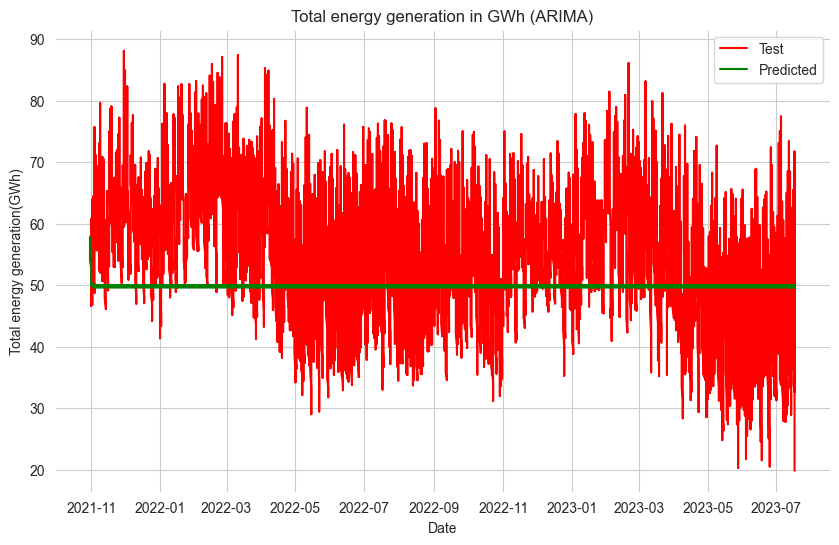

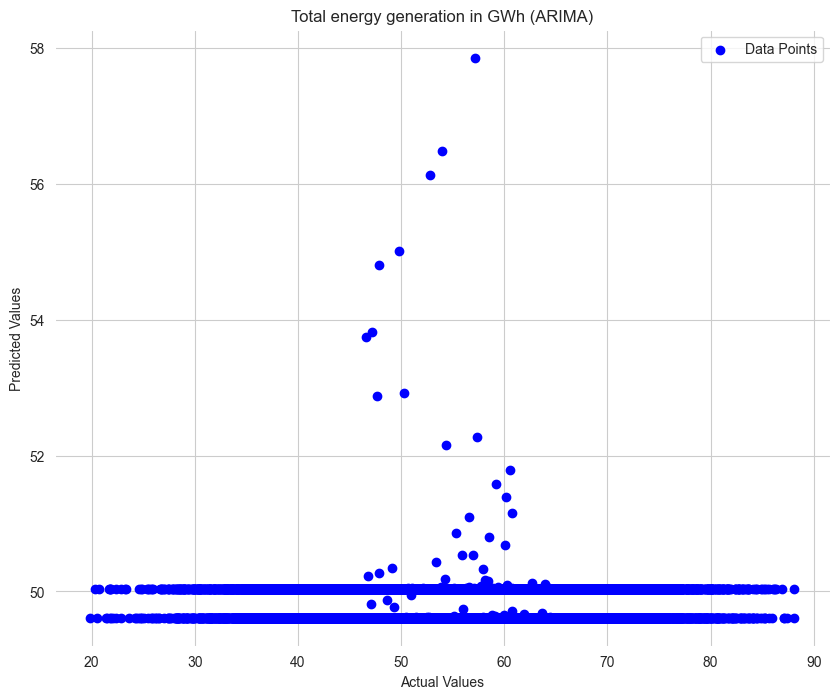

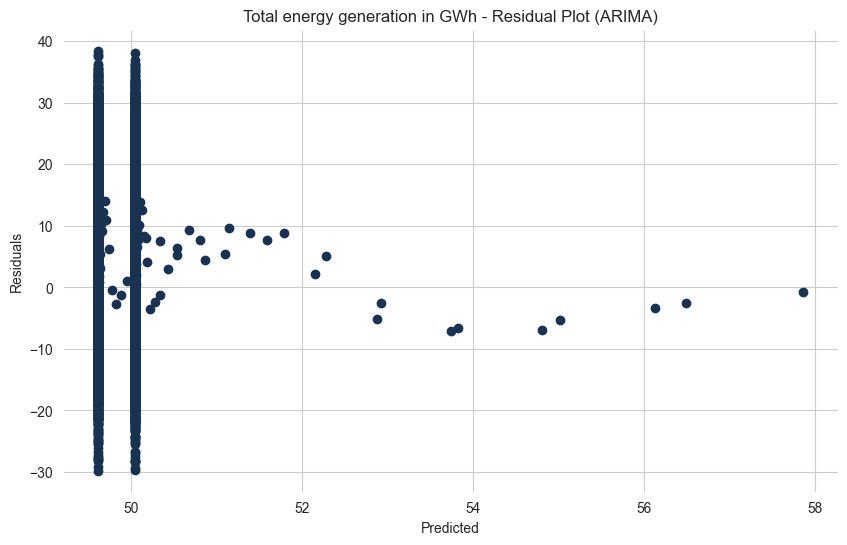

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                59903
Model:             SARIMAX(1, 0, 0)x(2, 1, 0, 2)   Log Likelihood             -131686.809
Date:                           Sat, 29 Jul 2023   AIC                         263381.619
Time:                                   20:26:13   BIC                         263417.620
Sample:                                        0   HQIC                        263392.802
                                         - 59903                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8818      0.001    637.901      0.000       0.879       0.884
ar.S.L2       -0.0491      0.002    -29.555

In [ ]:
# Assuming you have already loaded the data into the 'data_df' DataFrame
# and specified the 'target' column name, similar to your initial code.
# Copying the DataFrame and converting 'Date' to datetime format
#require(forecast)
df_c = data_df.copy()
df_c['Date'] = pd.to_datetime(df_c['Date'])

# Setting 'Date' as the index for time series data (if not already done)
df_c.set_index('Date', inplace=True)

# Splitting the data into train and test sets
train_size = int(len(df_c) * 0.8)
train, test = df_c[:train_size], df_c[train_size:]

# Finding the best ARIMA parameters with seasonal differencing using auto_arima
#stepwise_fit = auto_arima(train[target], seasonal=True, m=4, error_action='ignore', suppress_warnings=True)

#stepwise_fit = 
arima_model =  pm.auto_arima(train[target], start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, 
                         m=3, #12 is the frequncy of the cycle
                         start_P=0, 
                         seasonal=True, #set to seasonal
                         d=None, 
                         D=1, #order of the seasonal differencing
                         trace=False,
                         error_action='ignore',  
                         suppress_warnings=True, 
                         stepwise=True)
forecast(arima_model)
# Fitting the ARIMA model with the best parameters
#arima_model = stepwise_fit.fit(train[target])

# Making predictions on the test set
y_pred = arima_model.predict(n_periods=len(test))

# Computing the error metrics
rmse = np.sqrt(mean_squared_error(test[target], y_pred))
mse = mean_squared_error(test[target], y_pred)
mae = mean_absolute_error(test[target], y_pred)
r2 = r2_score(test[target], y_pred)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)


# Plotting the results
plt.figure(figsize=(10, 6))
#plt.plot(train.index, train[target], label='Train', color='blue')
plt.plot(test.index, test[target], label='Test', color='red')
plt.plot(test.index, y_pred, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel(ylable_target)
plt.title(title_main + ' (ARIMA)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(test[target].values, y_pred, label='Data Points', color='blue')
#plt.plot([test[target].min(), test[target].max()], [test[target].min(), test[target].max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (ARIMA)')
plt.legend()
plt.show()

# Plotting the residuals
residuals = test[target].values - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title(title_main + ' - Residual Plot (ARIMA)')
plt.show()
print(arima_model.summary())

In [73]:
# Assuming you have already loaded the data into the 'data_df' DataFrame
# and specified the 'target' column name, similar to your initial code.
# Copying the DataFrame and converting 'Date' to datetime format
df_c = data_df.copy()
df_c['Date'] = pd.to_datetime(df_c['Date'])

# Setting 'Date' as the index for time series data (if not already done)
df_c.set_index('Date', inplace=True)

# Splitting the data into train and test sets
train_size = int(len(df_c) * 0.8)
train, test = df_c[:train_size], df_c[train_size:]

# Finding the best ARIMA parameters with seasonal differencing using auto_arima
#stepwise_fit = auto_arima(train[target], seasonal=True, m=4, error_action='ignore', suppress_warnings=True)

#stepwise_fit = 
arima_model =  pm.auto_arima(train[target], start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, 
                         m=4, #12 is the frequncy of the cycle
                         start_P=0, 
                         seasonal=True, #set to seasonal
                         d=None, 
                         D=1, #order of the seasonal differencing
                         trace=False,
                         error_action='ignore',  
                         suppress_warnings=True, 
                         stepwise=True)

# Fitting the ARIMA model with the best parameters
#arima_model = stepwise_fit.fit(train[target])

# Making predictions on the test set
y_pred = arima_model.predict(n_periods=len(test))

# Computing the error metrics
rmse = np.sqrt(mean_squared_error(test[target], y_pred))
mse = mean_squared_error(test[target], y_pred)
mae = mean_absolute_error(test[target], y_pred)
r2 = r2_score(test[target], y_pred)

print("RMSE:", rmse)
print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)


# Plotting the results
plt.figure(figsize=(10, 6))
#plt.plot(train.index, train[target], label='Train', color='blue')
plt.plot(test.index, test[target], label='Test', color='red')
plt.plot(test.index, y_pred, label='Predicted', color='green')
plt.xlabel('Date')
plt.ylabel(ylable_target)
plt.title(title_main + ' (ARIMA)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values
plt.figure(figsize=(10, 8))
plt.scatter(test[target].values, y_pred, label='Data Points', color='blue')
#plt.plot([test[target].min(), test[target].max()], [test[target].min(), test[target].max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (ARIMA)')
plt.legend()
plt.show()

# Plotting the residuals
residuals = test[target].values - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals)
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title(title_main + ' - Residual Plot (ARIMA)')
plt.show()
print(arima_model.summary())

: 

: 

In [35]:
def sarimax_forecast(SARIMAX_model, periods=24):
    # Forecast
    n_periods = periods

    forecast_df = pd.DataFrame({"month_index":pd.date_range(df.index[-1], periods = n_periods, freq='MS').month},
                    index = pd.date_range(df.index[-1]+ pd.DateOffset(months=1), periods = n_periods, freq='MS'))

    fitted, confint = SARIMAX_model.predict(n_periods=n_periods, 
                                            return_conf_int=True,
                                            exogenous=forecast_df[['month_index']])
    index_of_fc = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods = n_periods, freq='MS')

    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=index_of_fc)
    lower_series = pd.Series(confint[:, 0], index=index_of_fc)
    upper_series = pd.Series(confint[:, 1], index=index_of_fc)

    # Plot
    plt.figure(figsize=(15,7))
    plt.plot(df["#Passengers"], color='#1f76b4')
    plt.plot(fitted_series, color='darkgreen')
    plt.fill_between(lower_series.index, 
                    lower_series, 
                    upper_series, 
                    color='k', alpha=.15)

    plt.title("SARIMAX - Forecast of Airline Passengers")
    plt.show()

sarimax_forecast(SARIMAX_model, periods=24)


NameError: name 'SARIMAX_model' is not defined

In [57]:
#df_c = data_df.copy()
#df_c['Date'] = pd.to_datetime(df_c['Date'])
#df_c[target] = df_c[target].rolling(window=12).mean()
##
##
df_c = data_df.copy()
df_c['Date'] = pd.to_datetime(df_c['Date'])
df_c[target] = df_c[target].rolling(window=24).mean()
train= df_c[target].dropna()
#train= df_c[target]
#Standard ARIMA Model
ARIMA_model = pm.auto_arima(train, 
                      start_p=1, 
                      start_q=1,
                      test='adf', # use adftest to find optimal 'd'
                      max_p=3, max_q=3, # maximum p and q
                      m=1, # frequency of series (if m==1, seasonal is set to FALSE automatically)
                      d=None,# let model determine 'd'
                      seasonal=False, # No Seasonality for standard ARIMA
                      trace=False, #logs 
                      error_action='warn', #shows errors ('ignore' silences these)
                      suppress_warnings=True,
                      stepwise=True)
print(ARIMA_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                74856
Model:               SARIMAX(3, 0, 3)   Log Likelihood              106111.589
Date:                Sat, 29 Jul 2023   AIC                        -212209.178
Time:                        23:48:59   BIC                        -212144.614
Sample:                             0   HQIC                       -212189.326
                              - 74856                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          2.9377      0.002   1631.505      0.000       2.934       2.941
ar.L2         -2.8810      0.003   -828.263      0.000      -2.888      -2.874
ar.L3          0.9433      0.002    561.257      0.0

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


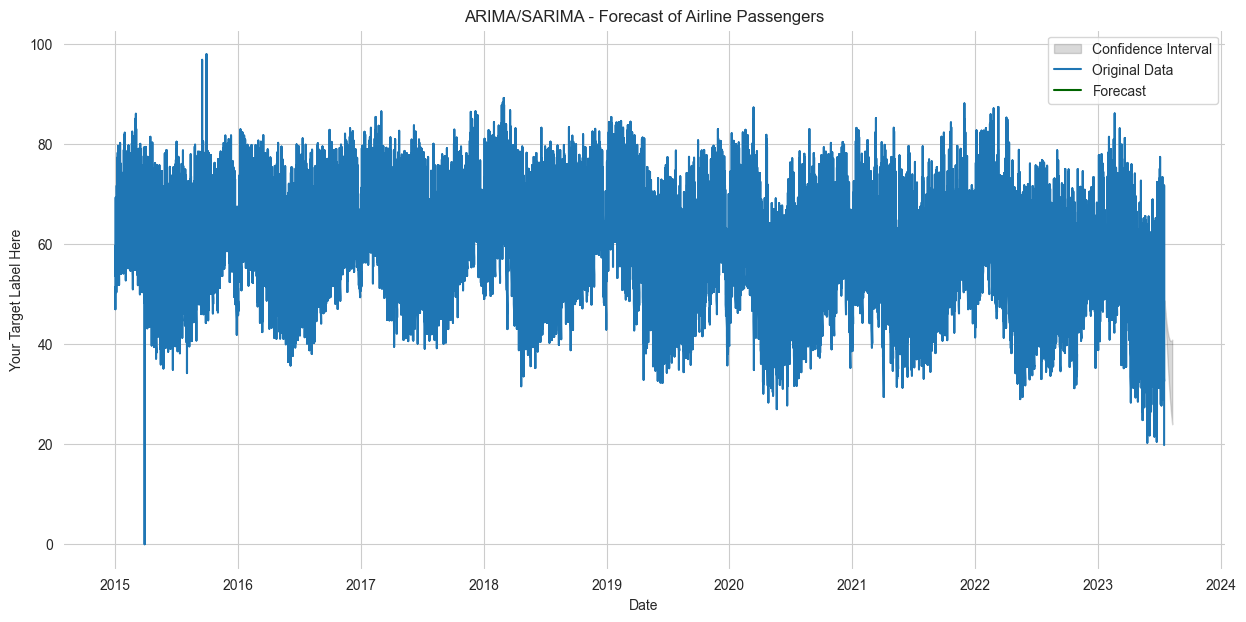

In [67]:
def forecast(ARIMA_model, periods=24):
    df_c = data_df.copy()
    df_c['Date'] = pd.to_datetime(df_c['Date'])
    
    # Forecast
    n_periods = periods
    fitted, confint = ARIMA_model.predict(n_periods=n_periods, return_conf_int=True)
    
    # Calculate the next date after the last date in the index
    last_date = df_c['Date'].iloc[-1]
    next_date = last_date + pd.DateOffset(days=1)  # Use DateOffset of 1 day for daily data
    
    # Create the date range for forecast
    index_of_fc = pd.date_range(start=next_date, periods=n_periods, freq='D')  # Use 'D' for daily frequency

    # make series for plotting purpose
    fitted_series = pd.Series(fitted, index=index_of_fc)
    lower_series = pd.Series(confint[:, 0], index=index_of_fc)
    upper_series = pd.Series(confint[:, 1], index=index_of_fc)

    # Plot
    plt.figure(figsize=(15,7))
    plt.fill_between(lower_series.index, 
                     lower_series, 
                     upper_series, 
                     color='k', alpha=.15, label='Confidence Interval')
    plt.plot(df_c['Date'], df_c[target], color='#1f76b4', label='Original Data')
    plt.plot(fitted_series, color='darkgreen', label='Forecast')
    plt.xlabel('Date')
    plt.ylabel('Your Target Label Here')
    plt.title("ARIMA/SARIMA - Forecast of Airline Passengers")
    plt.legend()
    plt.show()

forecast(ARIMA_model)


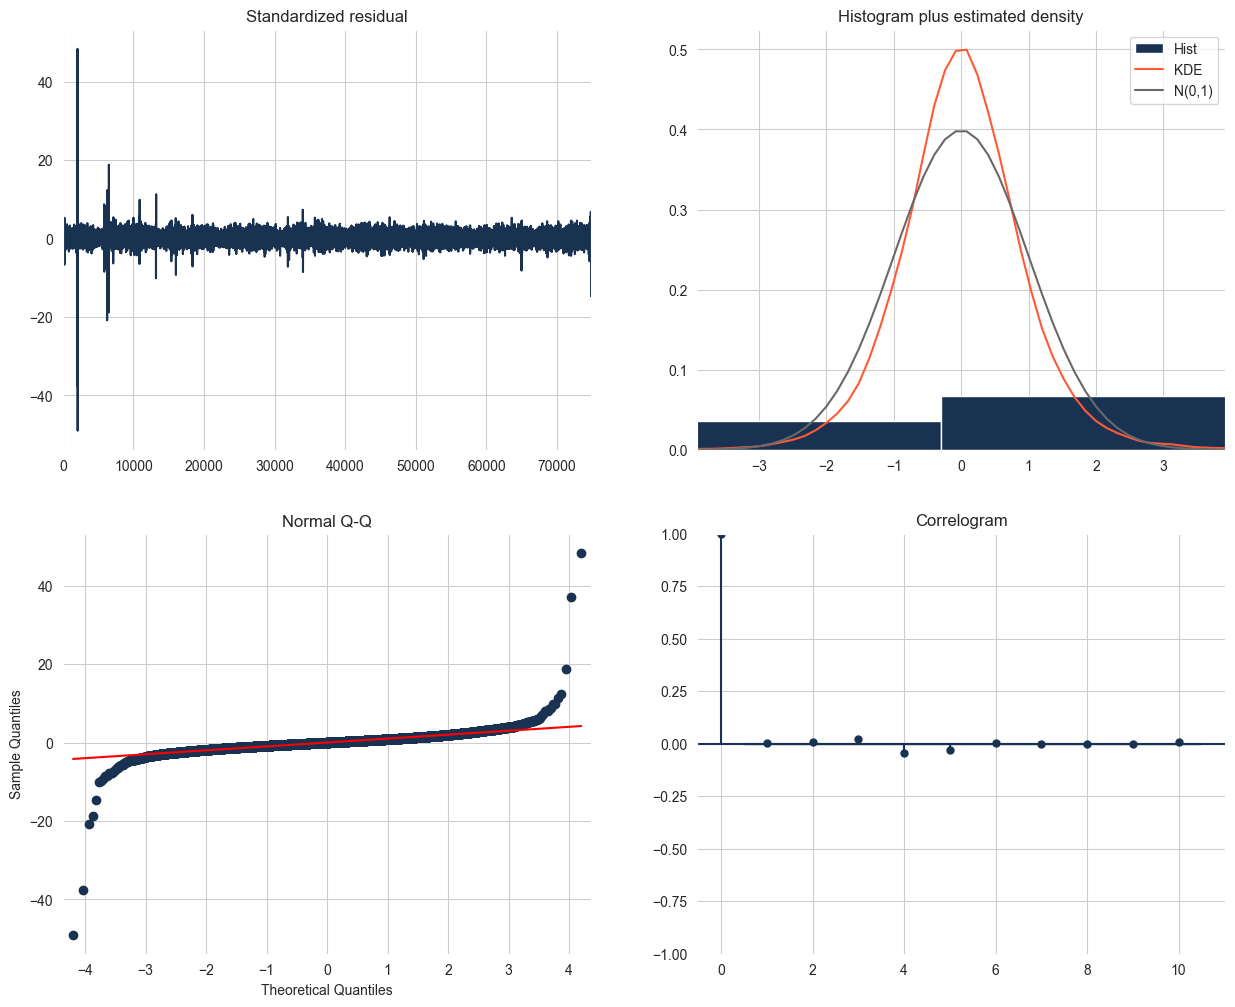

In [59]:
ARIMA_model.plot_diagnostics(figsize=(15,12))
plt.show()

In [65]:
#forecast(ARIMA_model)

In [60]:
df_c = data_df.copy()
df_c['Date'] = pd.to_datetime(df_c['Date'])
df_c[target] = df_c[target].rolling(window=24).mean()
train= df_c[target].dropna()
# Seasonal - fit stepwise auto-ARIMA
SARIMA_model = pm.auto_arima(train, start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, 
                         m=4, #12 is the frequncy of the cycle
                         start_P=0, 
                         seasonal=True, #set to seasonal
                         d=None, 
                         D=1, #order of the seasonal differencing
                         trace=False,
                         error_action='ignore',  
                         suppress_warnings=True, 
                         stepwise=True)

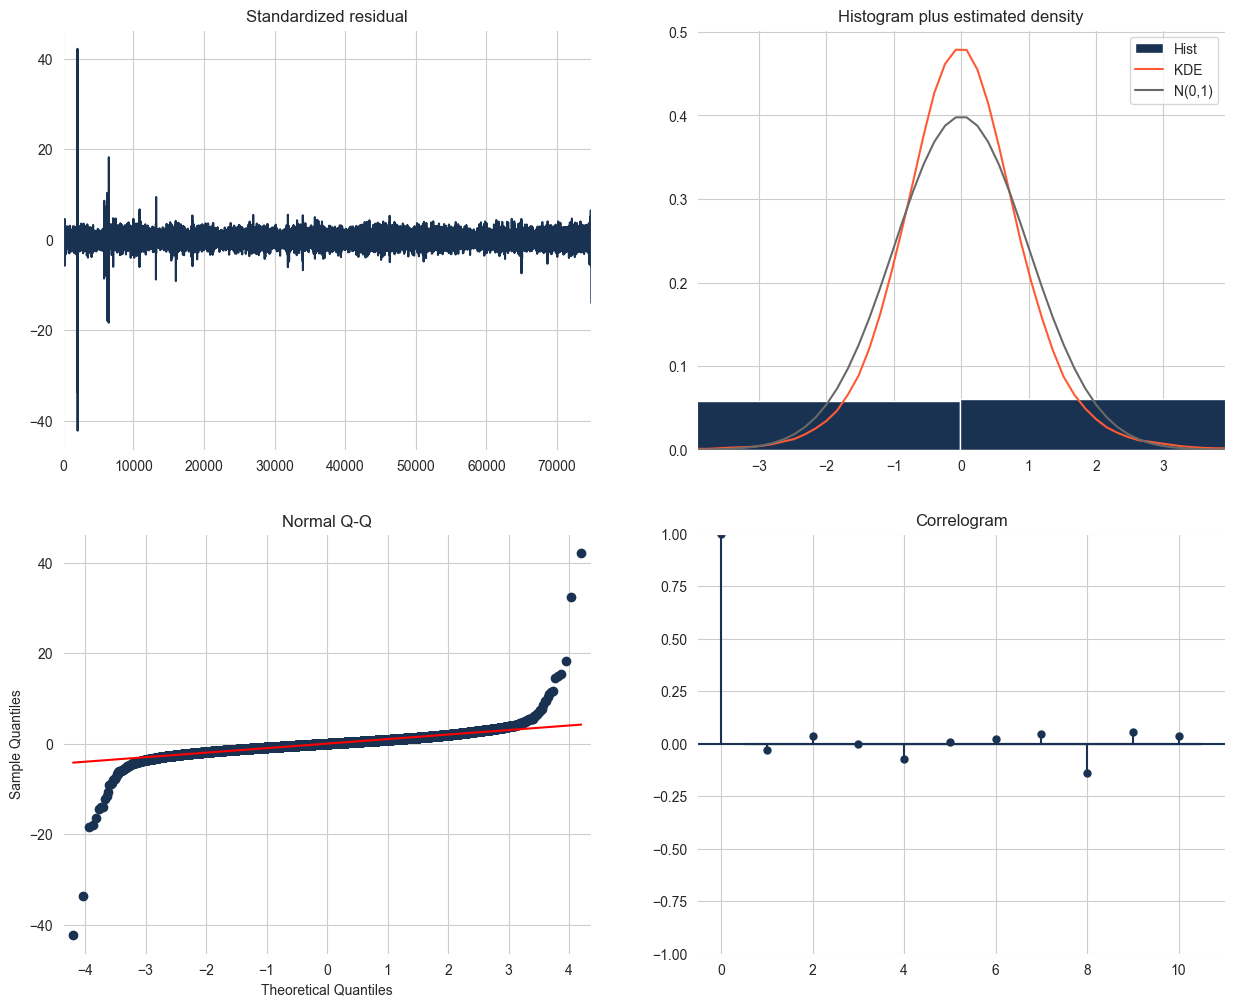

In [68]:
SARIMA_model.plot_diagnostics(figsize=(15,12))
plt.show()

/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/bimladanu/Documents/Github/Neufische_Bootcamp/Capstone_Project_2023/capstone_solar_energy/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


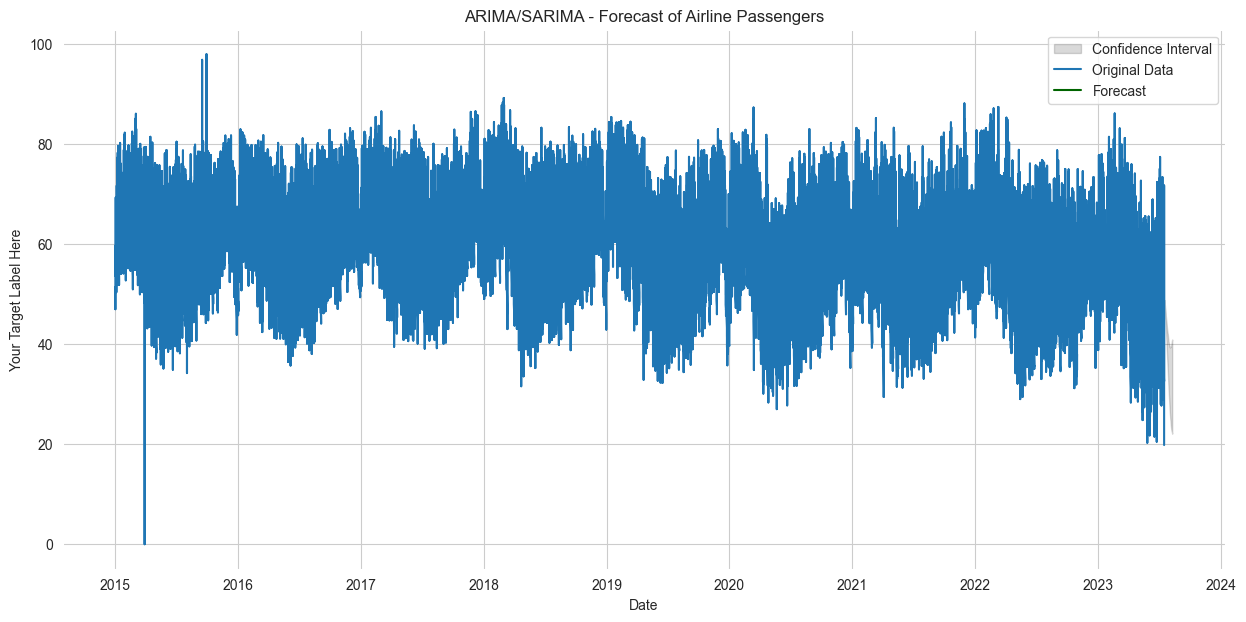

In [69]:
forecast(SARIMA_model)

In [ ]:
# Assuming you have defined these variables somewhere in your code
# target = 'Your_Target_Column_Name'
# ylable_target = 'Your_Y_Label'
# title_main = 'Your_Title'

# Assuming your data_df contains the relevant columns 'Date' and 'Your_Target_Column_Name'
# Assuming you have already split the data into train and test sets

# Split the data into training and testing sets
X = data_df['Date']
y = data_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Fitting the model (Random Forest Regressor)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Making predictions on the test set using Random Forest Regressor
y_pred_rf = rf_reg.predict(X_test)

# Computing the error metrics for Random Forest Regressor
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor:")
print("RMSE:", rmse_rf)
print("MSE:", mse_rf)
print("MAE:", mae_rf)
print("R2 Score:", r2_rf)

# Fit ARIMA model
# Assuming the 'target' column is the time series data
# If 'target' is not a time series, ARIMA may not be appropriate
arima_model = ARIMA(y_train, order=(5, 1, 0))
arima_model_fit = arima_model.fit()

# Making predictions on the test set using ARIMA
y_pred_arima, _, _ = arima_model_fit.forecast(len(y_test))

# Computing the error metrics for ARIMA
rmse_arima = np.sqrt(mean_squared_error(y_test, y_pred_arima))
mse_arima = mean_squared_error(y_test, y_pred_arima)
mae_arima = mean_absolute_error(y_test, y_pred_arima)
r2_arima = r2_score(y_test, y_pred_arima)

print("\nARIMA Model:")
print("RMSE:", rmse_arima)
print("MSE:", mse_arima)
print("MAE:", mae_arima)
print("R2 Score:", r2_arima)

# Plotting the results for Random Forest Regressor
plt.figure(figsize=(10, 6))
plt.scatter(X_test['Year'], y_test, label='Test', color='red')
plt.plot(X_test['Year'], y_pred_rf, label='Predicted (Random Forest)', color='green')
plt.xlabel('Year')
plt.ylabel(ylable_target)
plt.title(title_main + ' (Random Forest Regression)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values for Random Forest Regressor
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_rf, label='Data Points', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (Random Forest Regression)')
plt.legend()
plt.show()

# Plotting the results for ARIMA model
plt.figure(figsize=(10, 6))
plt.scatter(X_test.index, y_test, label='Test', color='red')
plt.plot(X_test.index, y_pred_arima, label='Predicted (ARIMA)', color='purple')
plt.xlabel('Date')
plt.ylabel(ylable_target)
plt.title(title_main + ' (ARIMA Model)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values for ARIMA model
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_arima, label='Data Points', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (ARIMA Model)')
plt.legend()
plt.show()

# Residuals for ARIMA model
residuals_arima = y_test - y_pred_arima
plt.scatter(y_pred_arima, residuals_arima)
plt.xlabel('Predicted (ARIMA)')
plt.ylabel('Residuals')
plt.title(title_main + ' - Residual Plot (ARIMA Model)')
plt.show()


In [ ]:

# Assuming you have defined these variables somewhere in your code
# target = 'Your_Target_Column_Name'
# ylable_target = 'Your_Y_Label'
# title_main = 'Your_Title'

# Assuming your data_df contains the relevant columns 'Date' and 'Your_Target_Column_Name'
# Assuming you have already split the data into train and test sets
# X_train, X_test, y_train, y_test = ...

# Split the data into training and testing sets
X = data_df['Date']
y = data_df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Fitting the model (Random Forest Regressor)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train, y_train)

# Making predictions on the test set using Random Forest Regressor
y_pred_rf = rf_reg.predict(X_test)

# Computing the error metrics for Random Forest Regressor
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mse_rf = mean_squared_error(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor:")
print("RMSE:", rmse_rf)
print("MSE:", mse_rf)
print("MAE:", mae_rf)
print("R2 Score:", r2_rf)

# Fit SARIMA model
# Assuming the 'target' column is the time series data
# If 'target' is not a time series, SARIMA may not be appropriate
order = (5, 1, 0)  # Non-seasonal order (p, d, q)
seasonal_order = (1, 1, 1, 12)  # Seasonal order (P, D, Q, Seasonal period)
sarima_model = SARIMAX(y_train, order=order, seasonal_order=seasonal_order)
sarima_model_fit = sarima_model.fit()

# Making predictions on the test set using SARIMA
y_pred_sarima = sarima_model_fit.forecast(len(y_test))

# Computing the error metrics for SARIMA
rmse_sarima = np.sqrt(mean_squared_error(y_test, y_pred_sarima))
mse_sarima = mean_squared_error(y_test, y_pred_sarima)
mae_sarima = mean_absolute_error(y_test, y_pred_sarima)
r2_sarima = r2_score(y_test, y_pred_sarima)

print("\nSARIMA Model:")
print("RMSE:", rmse_sarima)
print("MSE:", mse_sarima)
print("MAE:", mae_sarima)
print("R2 Score:", r2_sarima)

# Plotting the results for Random Forest Regressor
plt.figure(figsize=(10, 6))
plt.scatter(X_test['Year'], y_test, label='Test', color='red')
plt.plot(X_test['Year'], y_pred_rf, label='Predicted (Random Forest)', color='green')
plt.xlabel('Year')
plt.ylabel(ylable_target)
plt.title(title_main + ' (Random Forest Regression)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values for Random Forest Regressor
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_rf, label='Data Points', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (Random Forest Regression)')
plt.legend()
plt.show()

# Plotting the results for SARIMA model
plt.figure(figsize=(10, 6))
plt.scatter(X_test.index, y_test, label='Test', color='red')
plt.plot(X_test.index, y_pred_sarima, label='Predicted (SARIMA)', color='purple')
plt.xlabel('Date')
plt.ylabel(ylable_target)
plt.title(title_main + ' (SARIMA Model)')
plt.legend()
plt.show()

# Plotting the predicted vs actual values for SARIMA model
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_sarima, label='Data Points', color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Fit Line')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(title_main + ' (SARIMA Model)')
plt.legend()
plt.show()

# Residuals for SARIMA model
residuals_sarima = y_test - y_pred_sarima
plt.scatter(y_pred_sarima, residuals_sarima)
plt.xlabel('Predicted (SARIMA)')
plt.ylabel('Residuals')
plt.title(title_main + ' - Residual Plot (SARIMA Model)')
plt.show()
